In [1]:
!pip install seaborn contextily

pip: Command not found.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx
import geopandas as gpd
from pathlib import Path
import random
from sklearn.metrics import mutual_info_score
from tqdm.notebook import tqdm
import itertools

In [2]:
RAW_DATA_DIR = Path("data")
RAW_DISCHARGE_PATH = RAW_DATA_DIR / "usgs_discharge.csv"
RAW_BASIN_CHARS_PATH = RAW_DATA_DIR / "basin_characteristics.csv"
# Path to the ALIGNED rainfall data (as produced by process_rainfall.py)
ALIGNED_RAINFALL_PATH = Path("data/rainfall_series.csv")


In [3]:
from generate_training_data import load_and_align_data


EDA_OUTPUT_DIR = Path("eda_plots")

print("Loading data for EDA...")

discharge_pivot, aligned_rainfall_df, raw_basin_chars_df = load_and_align_data(use_all_forcings = False, input_data_dir = "data")

timeseries_to_analyze = {
    "discharge": discharge_pivot,
    "rainfall": aligned_rainfall_df
}


Loading data for EDA...
--- Loading and Aligning Data ---
LOADED DISCHARGE PIVOT from data/usgs_discharge.csv  siteCode    01367690  01367800  01367805  01377000  01377370  01377500  \
dateTime                                                                 
1990-01-01       NaN       NaN       NaN     120.0       NaN      42.0   
1990-01-02       NaN       NaN       NaN     111.0       NaN      30.0   
1990-01-03       NaN       NaN       NaN     108.0       NaN      27.0   
1990-01-04       NaN       NaN       NaN     109.0       NaN      27.0   
1990-01-05       NaN       NaN       NaN     109.0       NaN      27.0   

siteCode    01378500  01379000  01379500  01379530  ...  0146587310  01466500  \
dateTime                                            ...                         
1990-01-01      0.71      41.0     168.0       NaN  ...         NaN       2.4   
1990-01-02      0.63      46.0     160.0       NaN  ...         NaN       2.3   
1990-01-03      0.44      36.0     106.0      


--- 1. Analyzing Static Attribute Distributions (10 features) ---
Plotting distributions for 13 static characteristics...
Saved static attribute distribution plot to eda_plots/1_static_attribute_distributions.png


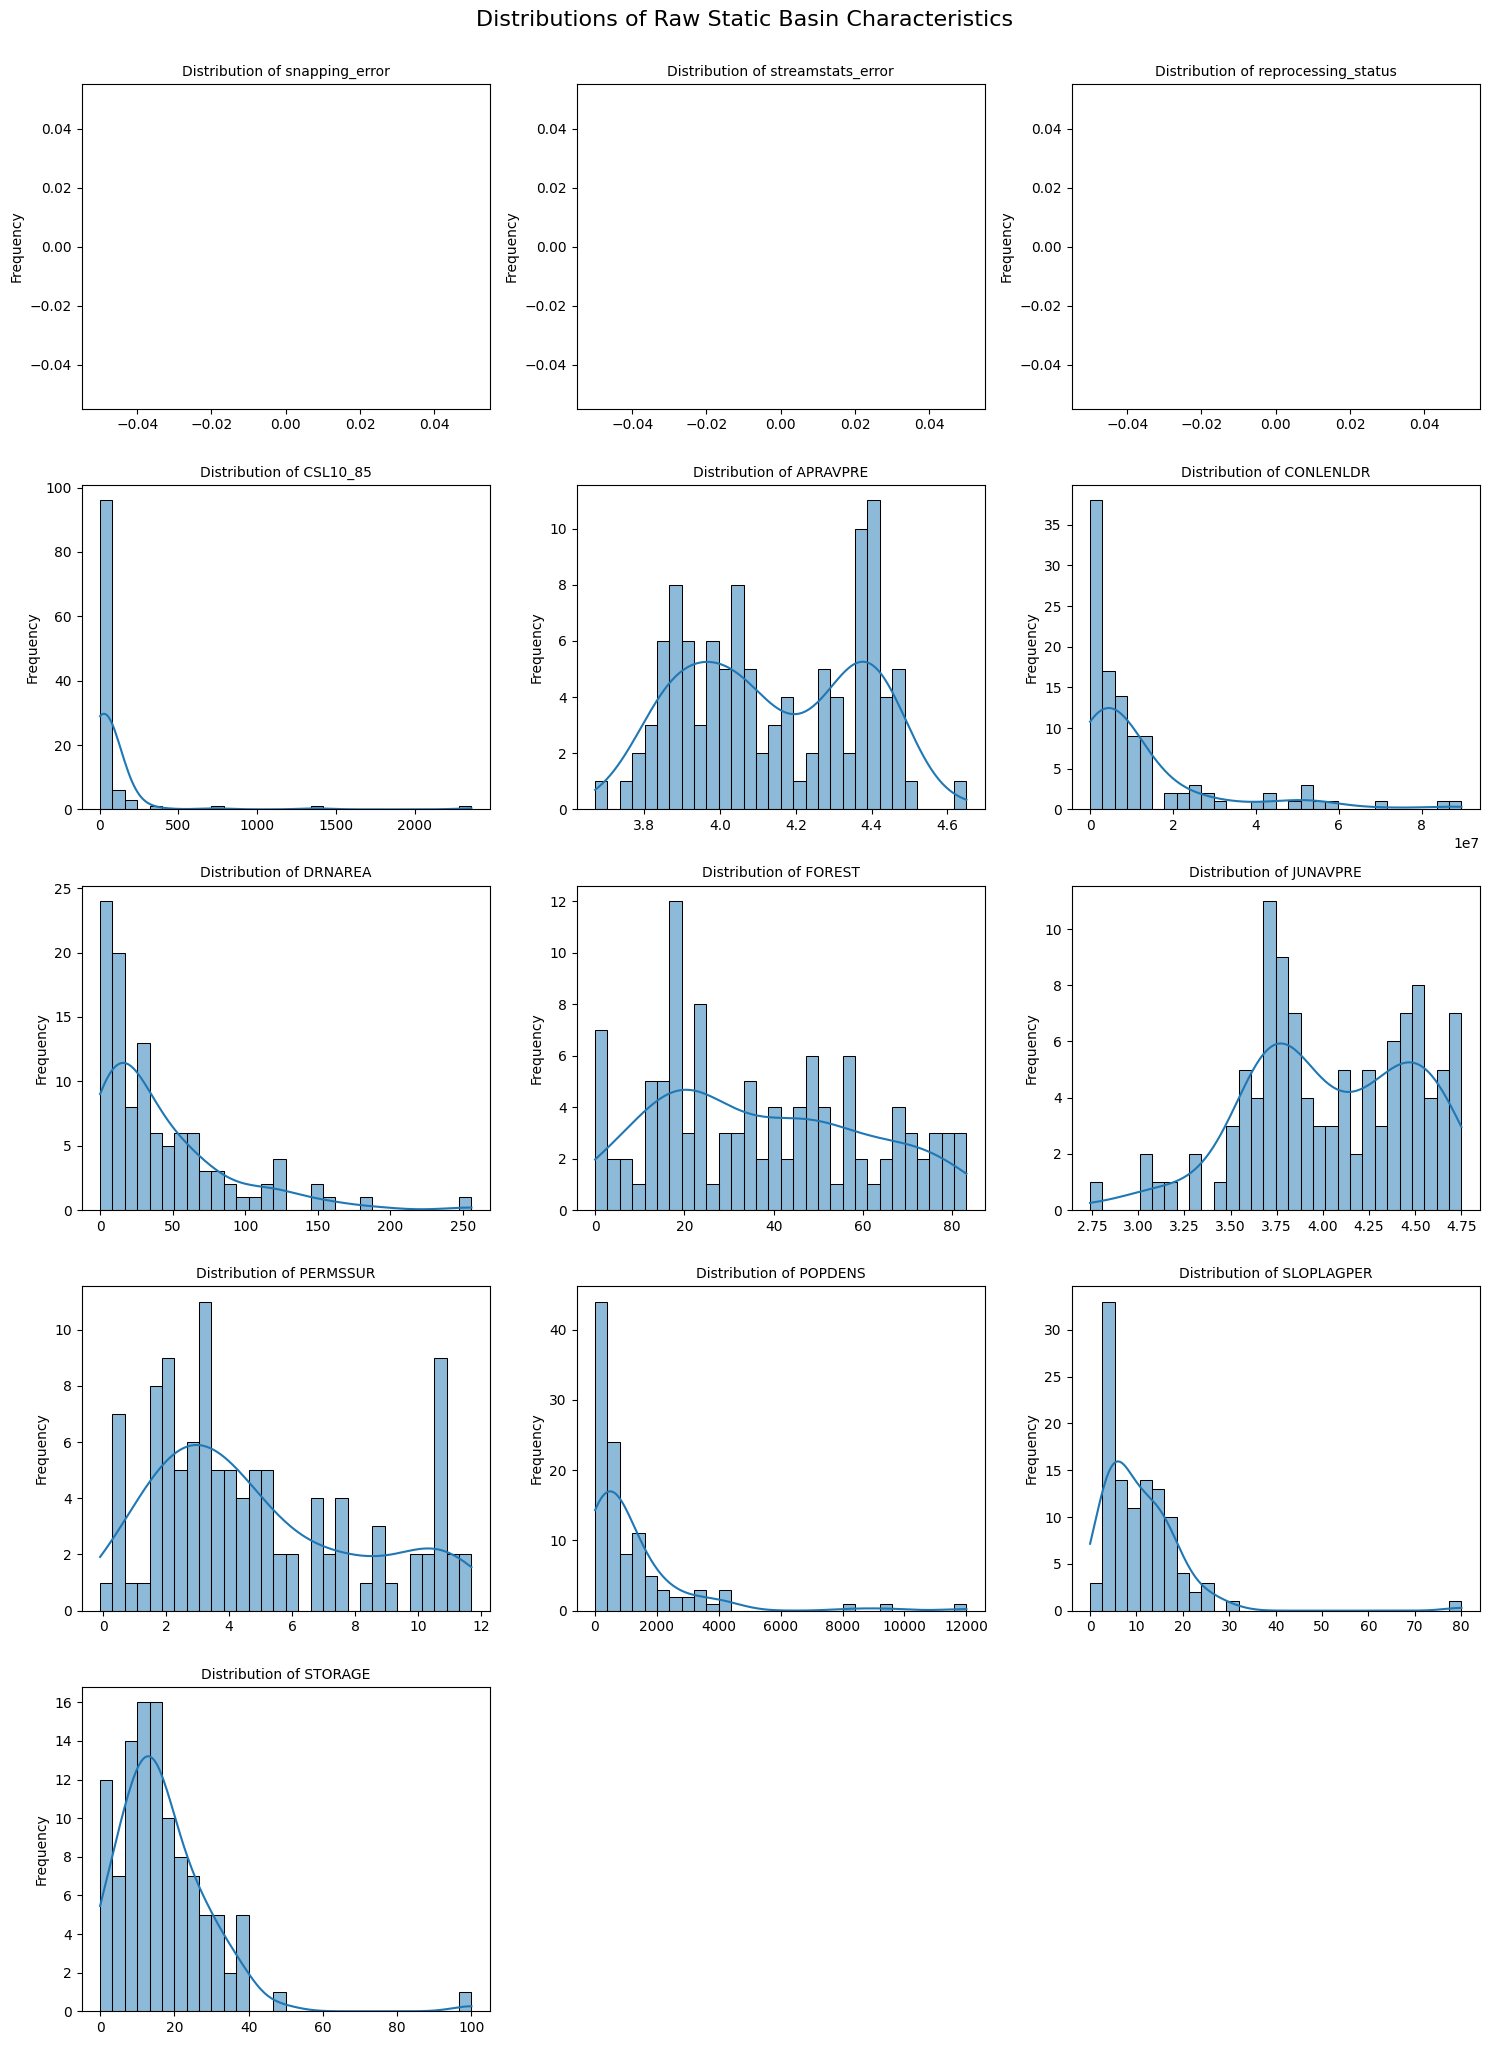

In [4]:
def plot_static_attribute_distributions(basin_chars_df):
    """Plots histograms for each static basin characteristic from the raw data."""
    print("\n--- 1. Analyzing Static Attribute Distributions (10 features) ---")
    
    # Coerce all columns to numeric, turning errors into NaN
    for col in basin_chars_df.columns:
        if basin_chars_df[col].dtype == 'object':
            basin_chars_df[col] = pd.to_numeric(basin_chars_df[col], errors='coerce')
            
    # Filter to only columns that are numeric and not coordinates
    plot_cols = [col for col in basin_chars_df.columns if 'lat' not in col and 'lon' not in col]
    
    num_cols = len(plot_cols)
    if num_cols == 0:
        print("No characteristic columns found to plot.")
        return
        
    print(f"Plotting distributions for {num_cols} static characteristics...")

    n_plot_cols = 3
    n_plot_rows = (num_cols + n_plot_cols - 1) // n_plot_cols
    fig, axes = plt.subplots(n_plot_rows, n_plot_cols, figsize=(15, n_plot_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        sns.histplot(basin_chars_df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=10)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.suptitle('Distributions of Raw Static Basin Characteristics', fontsize=16, y=1.02)
    
    output_path = EDA_OUTPUT_DIR / "1_static_attribute_distributions.png"
    plt.savefig(output_path, bbox_inches='tight')
    print(f"Saved static attribute distribution plot to {output_path}")
    plt.show()
    plt.close()

plot_static_attribute_distributions(raw_basin_chars_df.copy())



--- 2. Analyzing Dynamic Time Series Distributions (2 features) ---

Analyzing 'discharge' time series...
siteCode    01377000  01377500  01378500  01379000  01379500  01379530  \
dateTime                                                                 
1990-01-01     120.0      42.0      0.71      41.0     168.0       NaN   
1990-01-02     111.0      30.0      0.63      46.0     160.0       NaN   
1990-01-03     108.0      27.0      0.44      36.0     106.0       NaN   
1990-01-04     109.0      27.0      0.37      32.0      76.0       NaN   
1990-01-05     109.0      27.0      0.89      45.0      68.0       NaN   

siteCode    01379773  01379780  01379845  01380450  ...  0146587310  01466500  \
dateTime                                            ...                         
1990-01-01       5.8       6.2       NaN     235.0  ...         NaN       2.4   
1990-01-02       6.2       5.2       NaN     154.0  ...         NaN       2.3   
1990-01-03       6.4       6.0       NaN     127.0

/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


  Saved discharge distribution plot to eda_plots/2_distribution_discharge.png


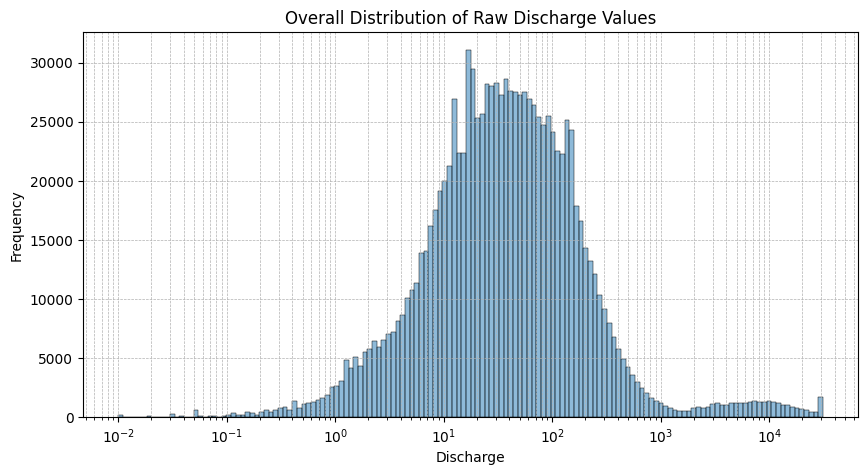

  Saved discharge time series plot to eda_plots/2_timeseries_sample_discharge.png


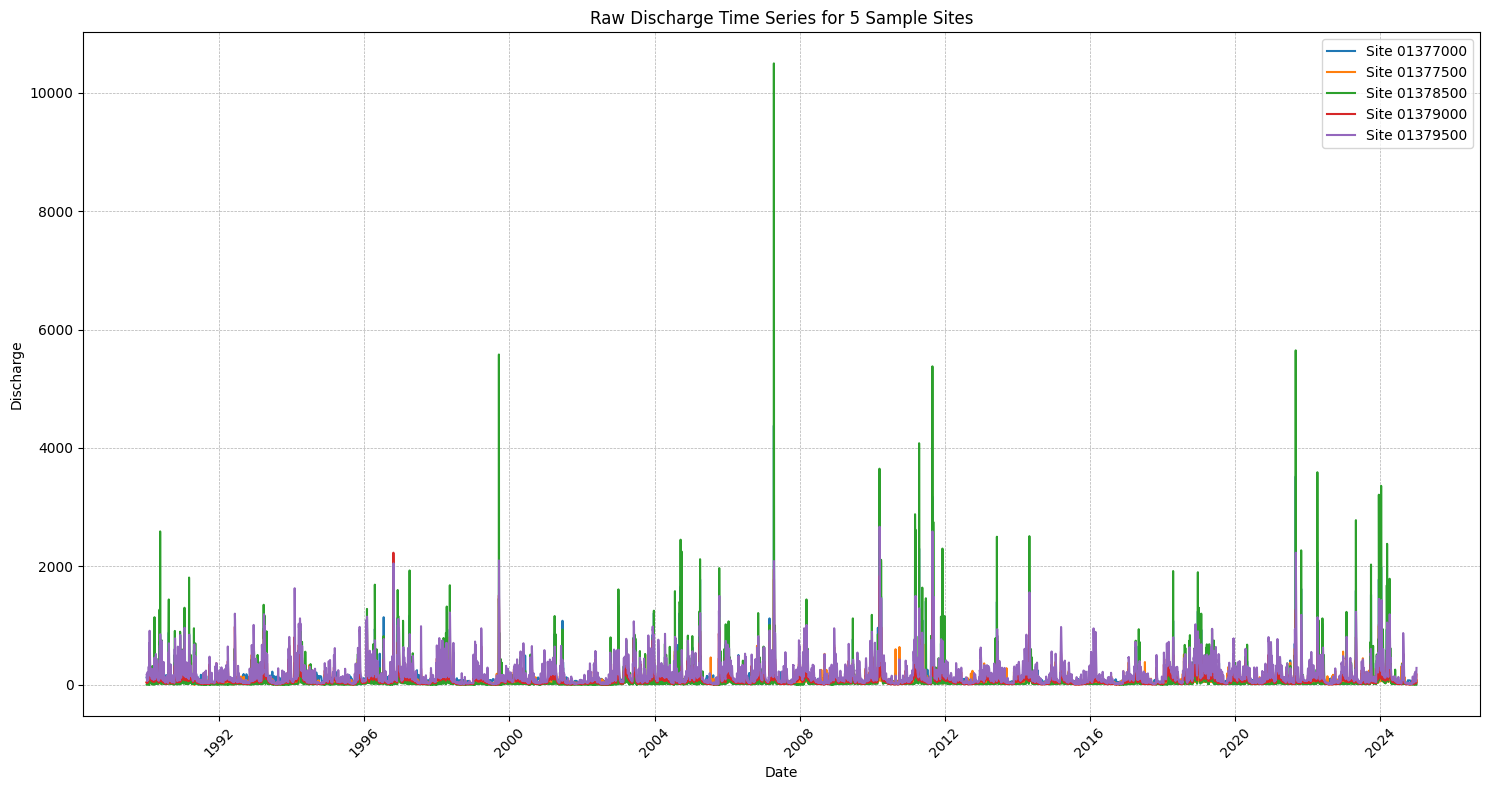


Analyzing 'rainfall' time series...
            01377000  01377500  01378500  01379000  01379500  01379530  \
dateTime                                                                 
2020-01-01      0.00      0.00      0.00      0.00      0.00      0.00   
2020-01-02      0.00      0.00      0.00      0.00      0.00      0.00   
2020-01-03      0.18      0.20      0.18      0.08      0.09      0.09   
2020-01-04      0.28      0.24      0.32      0.28      0.33      0.33   
2020-01-05      0.02      0.02      0.02      0.00      0.01      0.01   

            01379773  01379780  01379845  01380450  ...  0146587310  01466500  \
dateTime                                            ...                         
2020-01-01      0.00      0.00      0.04      0.00  ...        0.00      0.00   
2020-01-02      0.00      0.00      0.00      0.00  ...        0.00      0.00   
2020-01-03      0.17      0.17      0.10      0.15  ...        0.27      0.32   
2020-01-04      0.28      0.28      0.3

/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


  Saved rainfall distribution plot to eda_plots/2_distribution_rainfall.png


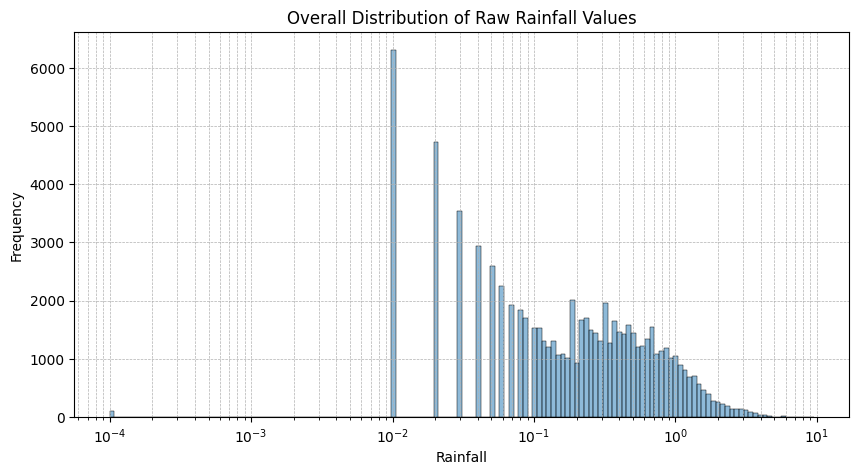

  Saved rainfall time series plot to eda_plots/2_timeseries_sample_rainfall.png


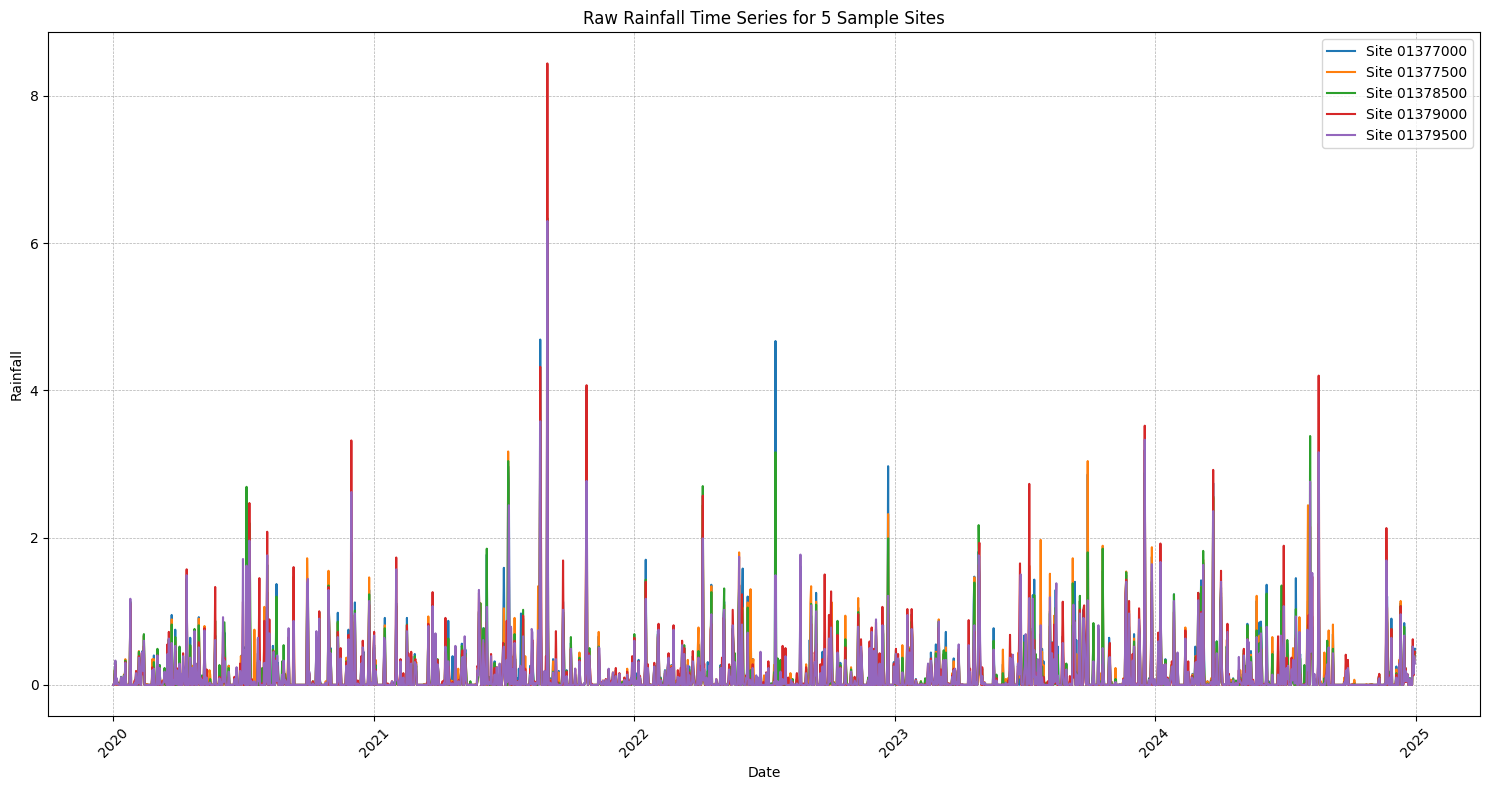

Index(['01377000', '01377500', '01378500', '01379000', '01379500'], dtype='object')
siteCode    01377000  01377500  01378500  01379000  01379500  01379530  \
dateTime                                                                 
2024-12-31      38.9      55.9      6.94     172.0     283.0      10.9   

siteCode    01379773  01379780  01379845  01380450  ...  0146587310  01466500  \
dateTime                                            ...                         
2024-12-31      22.3      24.7     118.0     310.0  ...         NaN       0.9   

siteCode    01466900  01467000  01467081  01467150  01475001  01477070  \
dateTime                                                                 
2024-12-31      44.4      83.9      13.4      27.9      8.17      3.61   

siteCode    01477120  01482500  
dateTime                        
2024-12-31      24.7      13.0  

[1 rows x 109 columns]
01377000
            01377000  01377500  01378500  01379000  01379500  01379530  \
dateTime            

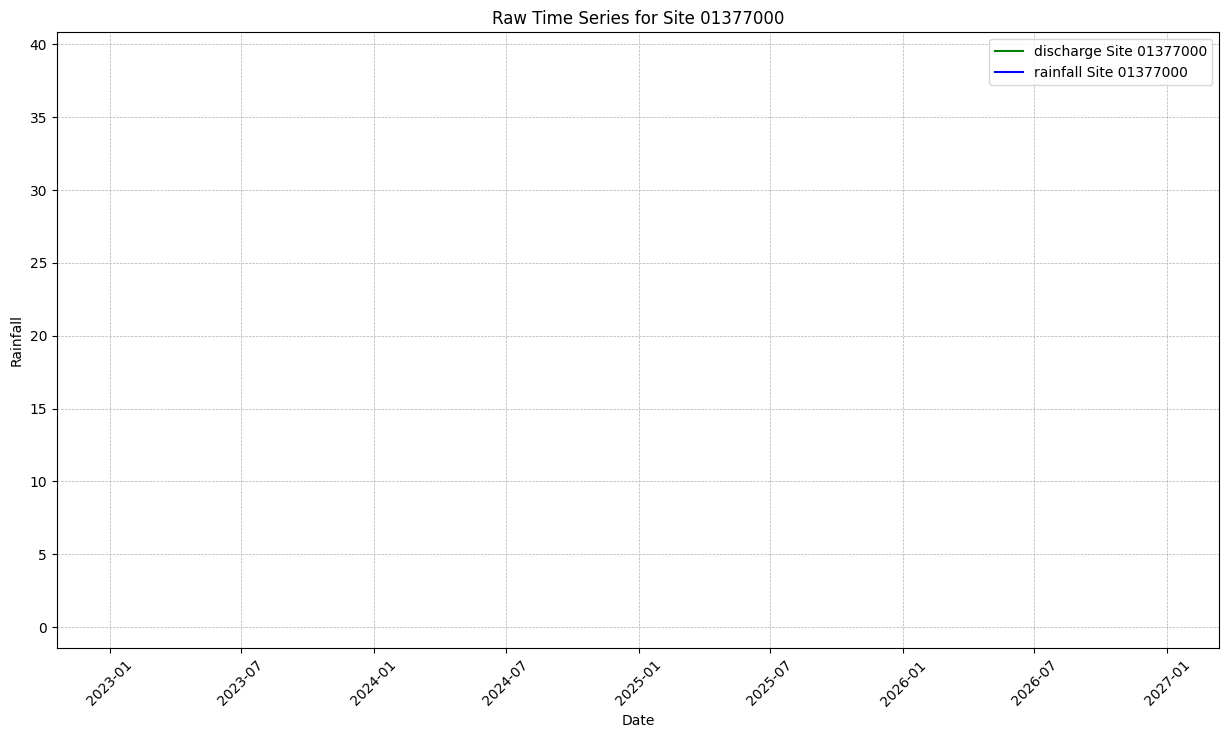

siteCode    01377000  01377500  01378500  01379000  01379500  01379530  \
dateTime                                                                 
2024-11-23      44.2      36.9      4.56      69.1     137.0      8.44   
2024-11-24      34.4      25.8      5.41      50.8     123.0      2.70   
2024-11-25      33.3      22.2      6.18      31.2      91.6      1.62   
2024-11-26      34.2      23.6      5.68      24.6      71.9      2.77   
2024-11-27      33.9      24.8      5.85      24.7      52.7      2.97   

siteCode    01379773  01379780  01379845  01380450  ...  0146587310  01466500  \
dateTime                                            ...                         
2024-11-23      2.24      0.03      67.2     150.0  ...         NaN      0.90   
2024-11-24      1.91      0.03      54.3     112.0  ...         NaN      0.88   
2024-11-25      1.68      0.03      41.1      82.2  ...         NaN      0.88   
2024-11-26      1.62      0.03      39.6      83.1  ...         NaN      0.8

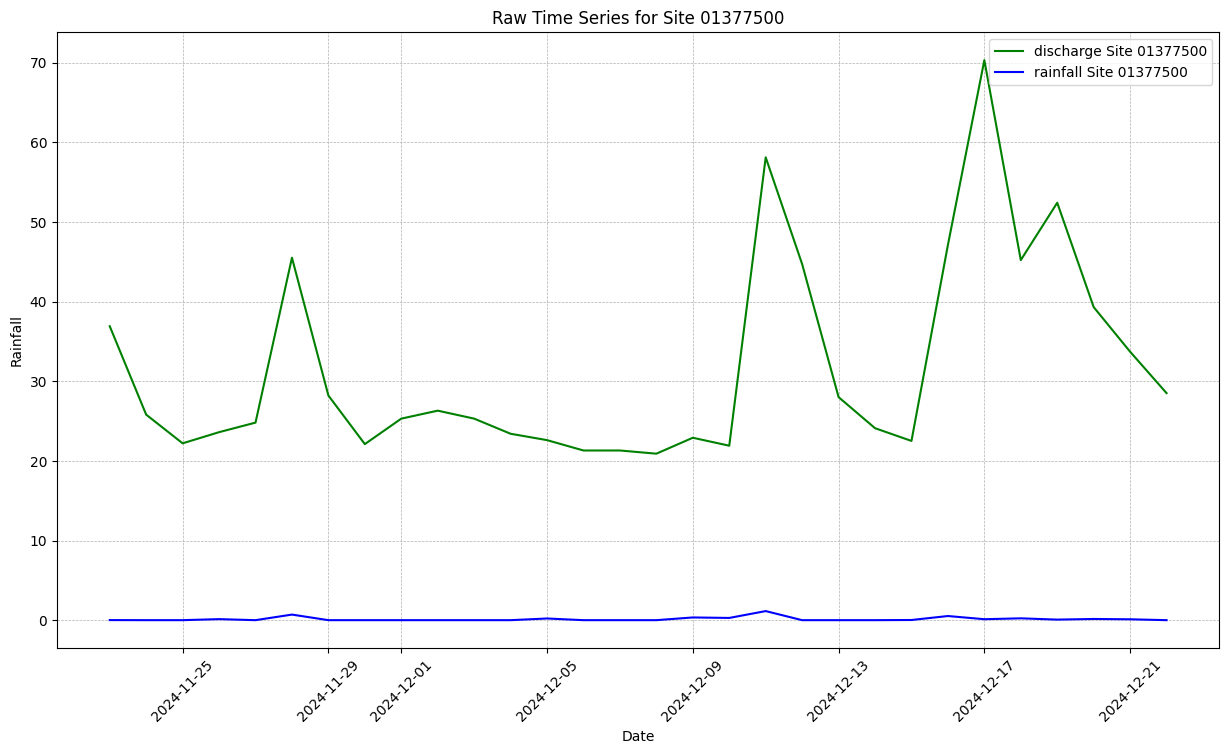

siteCode    01377000  01377500  01378500  01379000  01379500  01379530  \
dateTime                                                                 
2022-02-22      62.8      30.9      19.7     100.0     220.0       NaN   
2022-02-23      70.9      34.4      18.0     114.0     204.0       NaN   
2022-02-24      69.9      31.4      15.8     112.0     193.0       NaN   
2022-02-25      83.2      45.5      14.8     137.0     275.0       NaN   
2022-02-26      98.8      52.6      13.3     192.0     292.0       NaN   

siteCode    01379773  01379780  01379845  01380450  ...  0146587310  01466500  \
dateTime                                            ...                         
2022-02-22      16.1      16.4     117.0     236.0  ...        20.4      1.92   
2022-02-23      18.9      23.7     145.0     324.0  ...        20.5      1.94   
2022-02-24      18.1      24.5     140.0     299.0  ...        19.7      1.89   
2022-02-25      19.7      24.2     149.0     310.0  ...        29.5      2.3

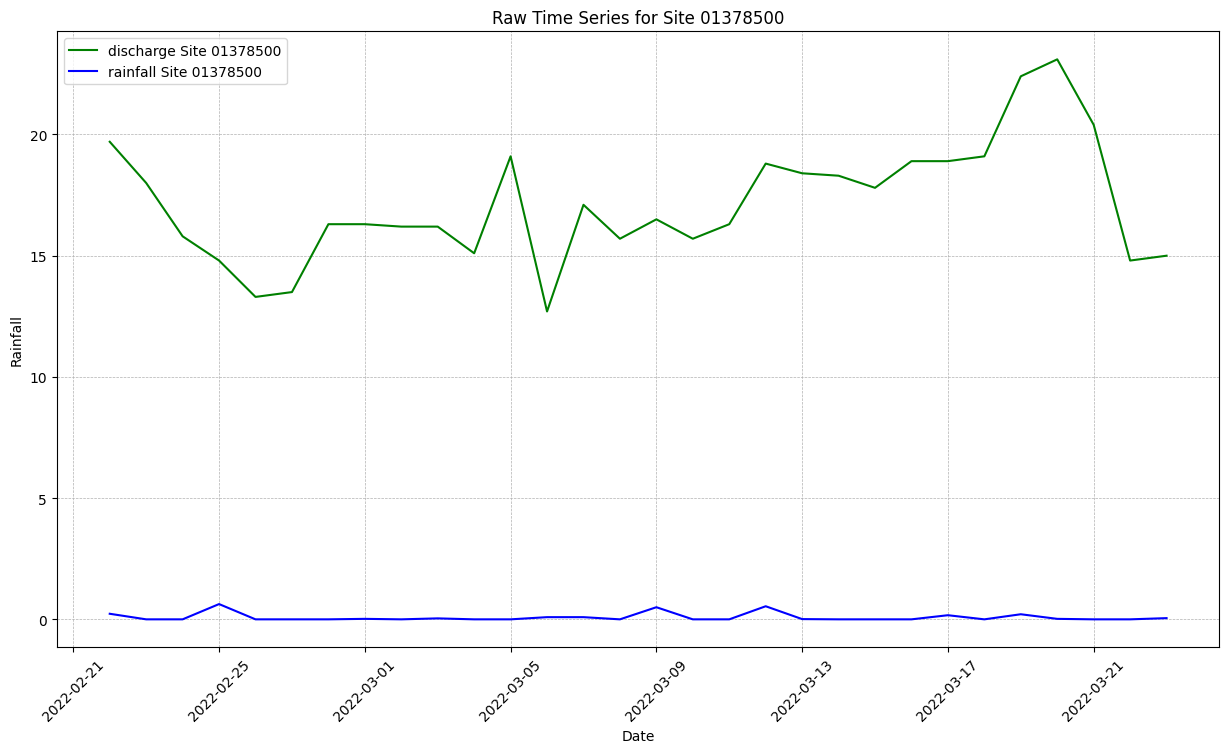

siteCode    01377000  01377500  01378500  01379000  01379500  01379530  \
dateTime                                                                 
2024-04-11     162.0      76.2     154.0     149.0     378.0      11.0   
2024-04-12     295.0     262.0     618.0     215.0     463.0     107.0   
2024-04-13     379.0     118.0     438.0     279.0     424.0      26.3   
2024-04-14     302.0      78.9     347.0     258.0     423.0      11.3   
2024-04-15     248.0      71.7     263.0     227.0     391.0      12.1   

siteCode    01379773  01379780  01379845  01380450  ...  0146587310  01466500  \
dateTime                                            ...                         
2024-04-11      28.5      31.9     223.0     460.0  ...        40.0      3.77   
2024-04-12      48.2      56.2     512.0    1090.0  ...        63.0      4.24   
2024-04-13      50.5      60.8     513.0    1170.0  ...        58.6      4.05   
2024-04-14      46.6      55.3     433.0     849.0  ...        48.1      3.7

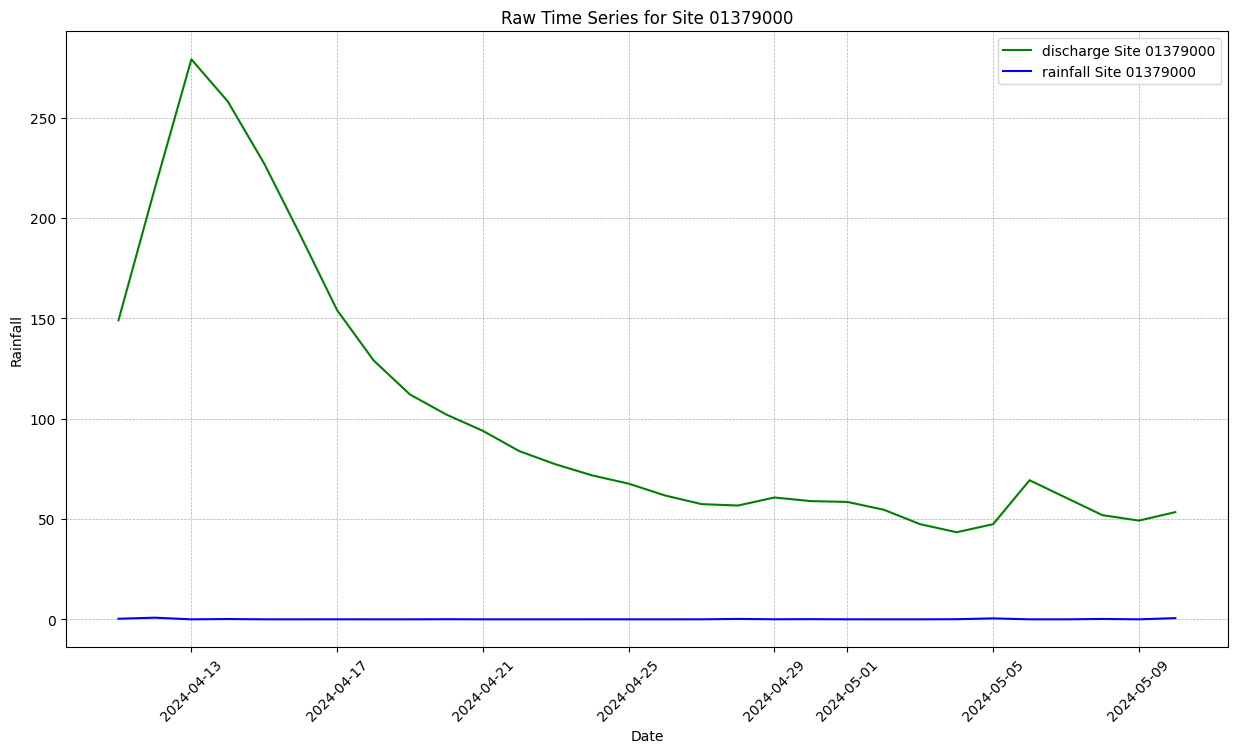

siteCode    01377000  01377500  01378500  01379000  01379500  01379530  \
dateTime                                                                 
2024-03-02     166.0     115.0     234.0     159.0     382.0     212.0   
2024-03-03     379.0     169.0     573.0     303.0     445.0     109.0   
2024-03-04     270.0      73.6     419.0     304.0     512.0      31.4   
2024-03-05     224.0     111.0     321.0     290.0     525.0      62.9   
2024-03-06     397.0     221.0     695.0     310.0     593.0     147.0   

siteCode    01379773  01379780  01379845  01380450  ...  0146587310  01466500  \
dateTime                                            ...                         
2024-03-02      20.7      22.6     173.0     353.0  ...        47.5      2.72   
2024-03-03      24.9      28.3     182.0     596.0  ...        70.0      3.22   
2024-03-04      24.9      28.0     163.0     427.0  ...        49.2      3.66   
2024-03-05      26.7      30.0     174.0     417.0  ...        45.5      3.5

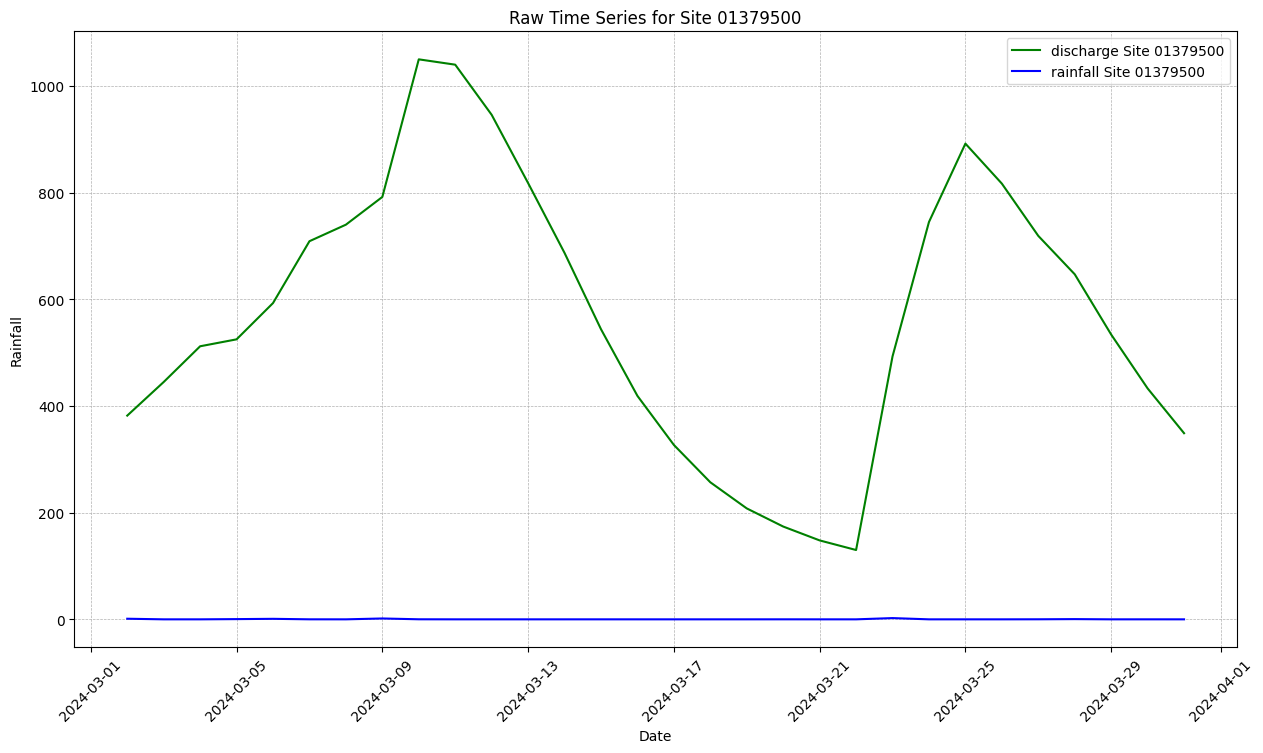

In [5]:
def plot_timeseries_data_analysis(timeseries_dict):
    """Analyzes raw time series data distributions and plots samples for each series."""
    print("\n--- 2. Analyzing Dynamic Time Series Distributions (2 features) ---")
    
    for name, df in timeseries_dict.items():
        print(f"\nAnalyzing '{name}' time series...")
        print(df.head())
        # a) Plot overall distribution of values
        plt.figure(figsize=(10, 5))
        sns.histplot(df.values.flatten(), bins=150, log_scale=True, kde = True)
        plt.title(f'Overall Distribution of Raw {name.title()} Values')
        plt.xlabel(name.title())
        plt.ylabel('Frequency')
        plt.grid(True, which="both", ls="--", linewidth=0.5)
        output_path = EDA_OUTPUT_DIR / f"2_distribution_{name}.png"
        plt.savefig(output_path, bbox_inches='tight')
        print(f"  Saved {name} distribution plot to {output_path}")
        plt.show()
        plt.close()        
        # b) Plot time series for a few sample sites
        num_sites_to_plot = min(5, df.shape[1])
        sample_sites = df.columns[:num_sites_to_plot]
        
        plt.figure(figsize=(15, 8))
        for site in sample_sites:
            plt.plot(df.index, df[site], label=f'Site {site}')
            
        plt.title(f'Raw {name.title()} Time Series for {num_sites_to_plot} Sample Sites')
        plt.xlabel('Date')
        plt.ylabel(name.title())
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True, which="both", ls="--", linewidth=0.5)
        plt.tight_layout()
        output_path = EDA_OUTPUT_DIR / f"2_timeseries_sample_{name}.png"
        plt.savefig(output_path, bbox_inches='tight')
        print(f"  Saved {name} time series plot to {output_path}")
        plt.show()
        plt.close()

    # c. plot a single site with both discharge and rainfall
    print(sample_sites)
    for site in sample_sites:
        plt.figure(figsize=(15, 8))
        start_date = random.randint(df.index.min().timestamp(), df.index.max().timestamp())
        end_date = start_date + 30 * 24 * 3600  # 30 days later
        start_date = pd.to_datetime(start_date, unit='s')
        end_date = pd.to_datetime(end_date, unit='s')
        for name, df in timeseries_dict.items():
            df_sample = df.loc[start_date:end_date]
            print(df_sample.head())
            print(site)
            if name == "rainfall":
                plt.plot(df_sample.index, df_sample[site], label=f'{name} Site {site}', color='blue')
            elif name == "discharge":
                plt.plot(df_sample.index, df_sample[site], label=f'{name} Site {site}', color='green')
        plt.title(f'Raw Time Series for Site {site}')
        plt.xlabel('Date')
        plt.ylabel(name.title())
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True, which="both", ls="--", linewidth=0.5)
        # plt.tight_layout()
        output_path = EDA_OUTPUT_DIR / f"2_site_sample_both.png"
        plt.savefig(output_path, bbox_inches='tight')
        print(f"  Saved {name} time series plot to {output_path}")
        plt.show()
        plt.close()
timeseries_to_analyze = {
    "discharge": discharge_pivot,
    "rainfall": aligned_rainfall_df
}
plot_timeseries_data_analysis(timeseries_to_analyze)


In [6]:
def visualize_missing_data(basin_chars_df, timeseries_dict):
    """Creates heatmaps to visualize missing data in all attributes."""
    print("\n--- 3. Analyzing Missing Data Coverage (All 12 features) ---")

    # a) Static Attributes Missingness
    plt.figure(figsize=(12, 8))
    sns.heatmap(basin_chars_df.set_index('site_no').isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Data in Static Basin Characteristics')
    plt.xlabel('Attributes')
    plt.ylabel('Site Number')
    output_path = EDA_OUTPUT_DIR / "3_missing_data_static.png"
    plt.savefig(output_path, bbox_inches='tight')
    print(f"Saved static missing data heatmap to {output_path}")
    plt.show()
    plt.close()

    # b) Dynamic Attributes Missingness
    for name, df in timeseries_dict.items():
        print(f"Checking for missing data in '{name}'...")
        # Check for missing dates in the index
        df.index = pd.to_datetime(df.index)
        date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
        missing_dates = date_range.difference(df.index)
        if not missing_dates.empty:
            print(f"  Warning: Found {len(missing_dates)} missing dates in the '{name}' time series index.")
        else:
            print(f"  '{name}' time series has a complete daily index for its covered period.")

        plt.figure(figsize=(15, 10))
        sns.heatmap(df.isnull().T, cbar=False, cmap='viridis')
        plt.title(f'Missing Data in {name.title()} Time Series')
        plt.xlabel('Date')
        plt.ylabel('Site Number')
        plt.xticks(rotation=45)
        locs, labels = plt.xticks()
        if len(locs) > 20:
            step = len(locs) // 10
            plt.xticks(locs[::step], labels[::step])
        plt.tight_layout()
        output_path = EDA_OUTPUT_DIR / f"3_missing_data_{name}.png"
        plt.savefig(output_path, bbox_inches='tight')
        print(f"  Saved {name} missing data heatmap to {output_path}")
        plt.show()
        plt.close()

visualize_missing_data(raw_basin_chars_df.copy(), timeseries_to_analyze)



--- 3. Analyzing Missing Data Coverage (All 12 features) ---


KeyError: "None of ['site_no'] are in the columns"

<Figure size 1200x800 with 0 Axes>


--- 4. Analyzing Geographical Coverage ---
Added OpenStreetMap basemap.
Saved geographical coverage map to eda_plots/4_geographical_coverage_map.png


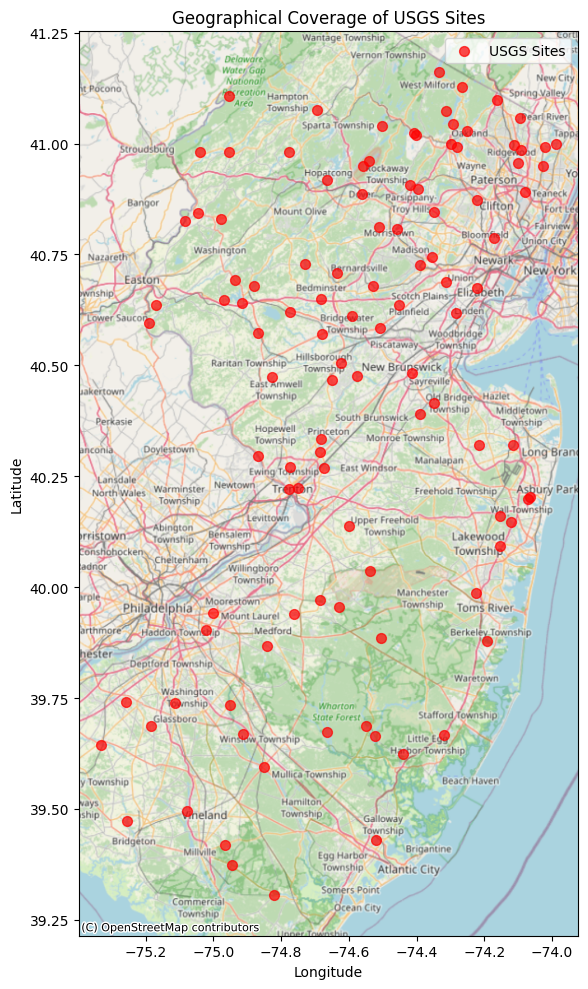

In [8]:

def plot_geographical_coverage(basin_chars_df):
    """Plots the monitoring sites on a map."""
    print("\n--- 4. Analyzing Geographical Coverage ---")
    
    coord_cols = None
    if 'latitude' in basin_chars_df.columns and 'longitude' in basin_chars_df.columns:
        coord_cols = ('latitude', 'longitude')
    elif 'original_lat' in basin_chars_df.columns and 'original_lon' in basin_chars_df.columns:
        coord_cols = ('original_lat', 'original_lon')

    if not coord_cols:
        print("Cannot plot geographical coverage: Coordinate columns not found.")
        return

    lat_col, lon_col = coord_cols
    gdf = gpd.GeoDataFrame(
        basin_chars_df.dropna(subset=[lat_col, lon_col]), 
        geometry=gpd.points_from_xy(basin_chars_df.dropna(subset=[lat_col, lon_col])[lon_col], 
                                    basin_chars_df.dropna(subset=[lat_col, lon_col])[lat_col])
    )
    gdf.set_crs(epsg=4326, inplace=True)

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf.plot(ax=ax, marker='o', color='red', markersize=50, alpha=0.7, label='USGS Sites')

    try:
        cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)
        print("Added OpenStreetMap basemap.")
    except Exception as e:
        print(f"Could not add basemap due to an error: {e}. Plotting on a plain axis.")

    ax.set_title('Geographical Coverage of USGS Sites')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    plt.tight_layout()
    output_path = EDA_OUTPUT_DIR / "4_geographical_coverage_map.png"
    plt.savefig(output_path, bbox_inches='tight')
    print(f"Saved geographical coverage map to {output_path}")
    plt.show()
    plt.close()



plot_geographical_coverage(raw_basin_chars_df.copy())


In [9]:
discharge_pivot.head()

siteCode,01377000,01377370,01377500,01378500,01379000,01379500,01379530,01379773,01379780,01379845,...,0146587310,01466500,01466900,01467000,01467081,01467150,01475001,01477070,01477120,01482500
dateTime,,,,,,,,,,,,,,,,,,,,,
2020-01-01,217.0,21.5,59.0,238.0,195.0,320.0,18.0,23.8,27.5,162.0,...,36.3,2.39,151.0,297.0,11.7,22.6,10.5,NaN,35.6,16.6
2020-01-02,150.0,16.6,43.0,123.0,172.0,317.0,11.8,22.1,26.3,136.0,...,31.6,2.28,144.0,267.0,9.0,16.8,10.0,NaN,31.0,13.1
2020-01-03,120.0,17.5,42.1,98.3,150.0,289.0,10.9,20.8,24.9,126.0,...,31.5,2.20,135.0,246.0,13.5,25.4,11.4,NaN,35.3,14.2
2020-01-04,119.0,26.5,66.2,127.0,146.0,291.0,36.6,23.1,27.2,159.0,...,35.3,2.25,136.0,261.0,24.1,37.4,12.5,NaN,43.5,20.4
2020-01-05,114.0,16.7,48.5,114.0,154.0,263.0,17.7,21.5,25.5,138.0,...,36.3,2.12,138.0,258.0,14.6,26.6,10.7,NaN,38.1,18.6



--- 5. Plotting Discharge Distribution ---


Text(0.5, 1.0, 'Overall Distribution of Raw Discharge Values')

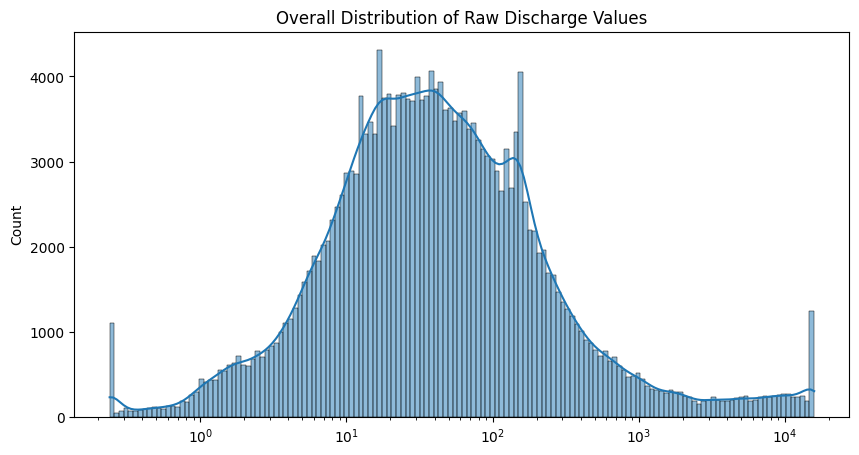

In [10]:
#plot discharge distribution
print("\n--- 5. Plotting Discharge Distribution ---")
plt.figure(figsize=(10, 5))
sns.histplot(discharge_pivot.values.flatten(), bins=150, log_scale=True, kde = True)
plt.title('Overall Distribution of Raw Discharge Values')

siteCode    01377000  01377370  01377500  01378500  01379000  01379500  \
dateTime                                                                 
2020-01-01     217.0      21.5      59.0     238.0     195.0     320.0   
2020-01-02     150.0      16.6      43.0     123.0     172.0     317.0   
2020-01-03     120.0      17.5      42.1      98.3     150.0     289.0   
2020-01-04     119.0      26.5      66.2     127.0     146.0     291.0   
2020-01-05     114.0      16.7      48.5     114.0     154.0     263.0   

siteCode    01379530  01379773  01379780  01379845  ...  0146587310  01466500  \
dateTime                                            ...                         
2020-01-01      18.0      23.8      27.5     162.0  ...        36.3      2.39   
2020-01-02      11.8      22.1      26.3     136.0  ...        31.6      2.28   
2020-01-03      10.9      20.8      24.9     126.0  ...        31.5      2.20   
2020-01-04      36.6      23.1      27.2     159.0  ...        35.3      2.2

/tmp/ipykernel_2761060/2428280409.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


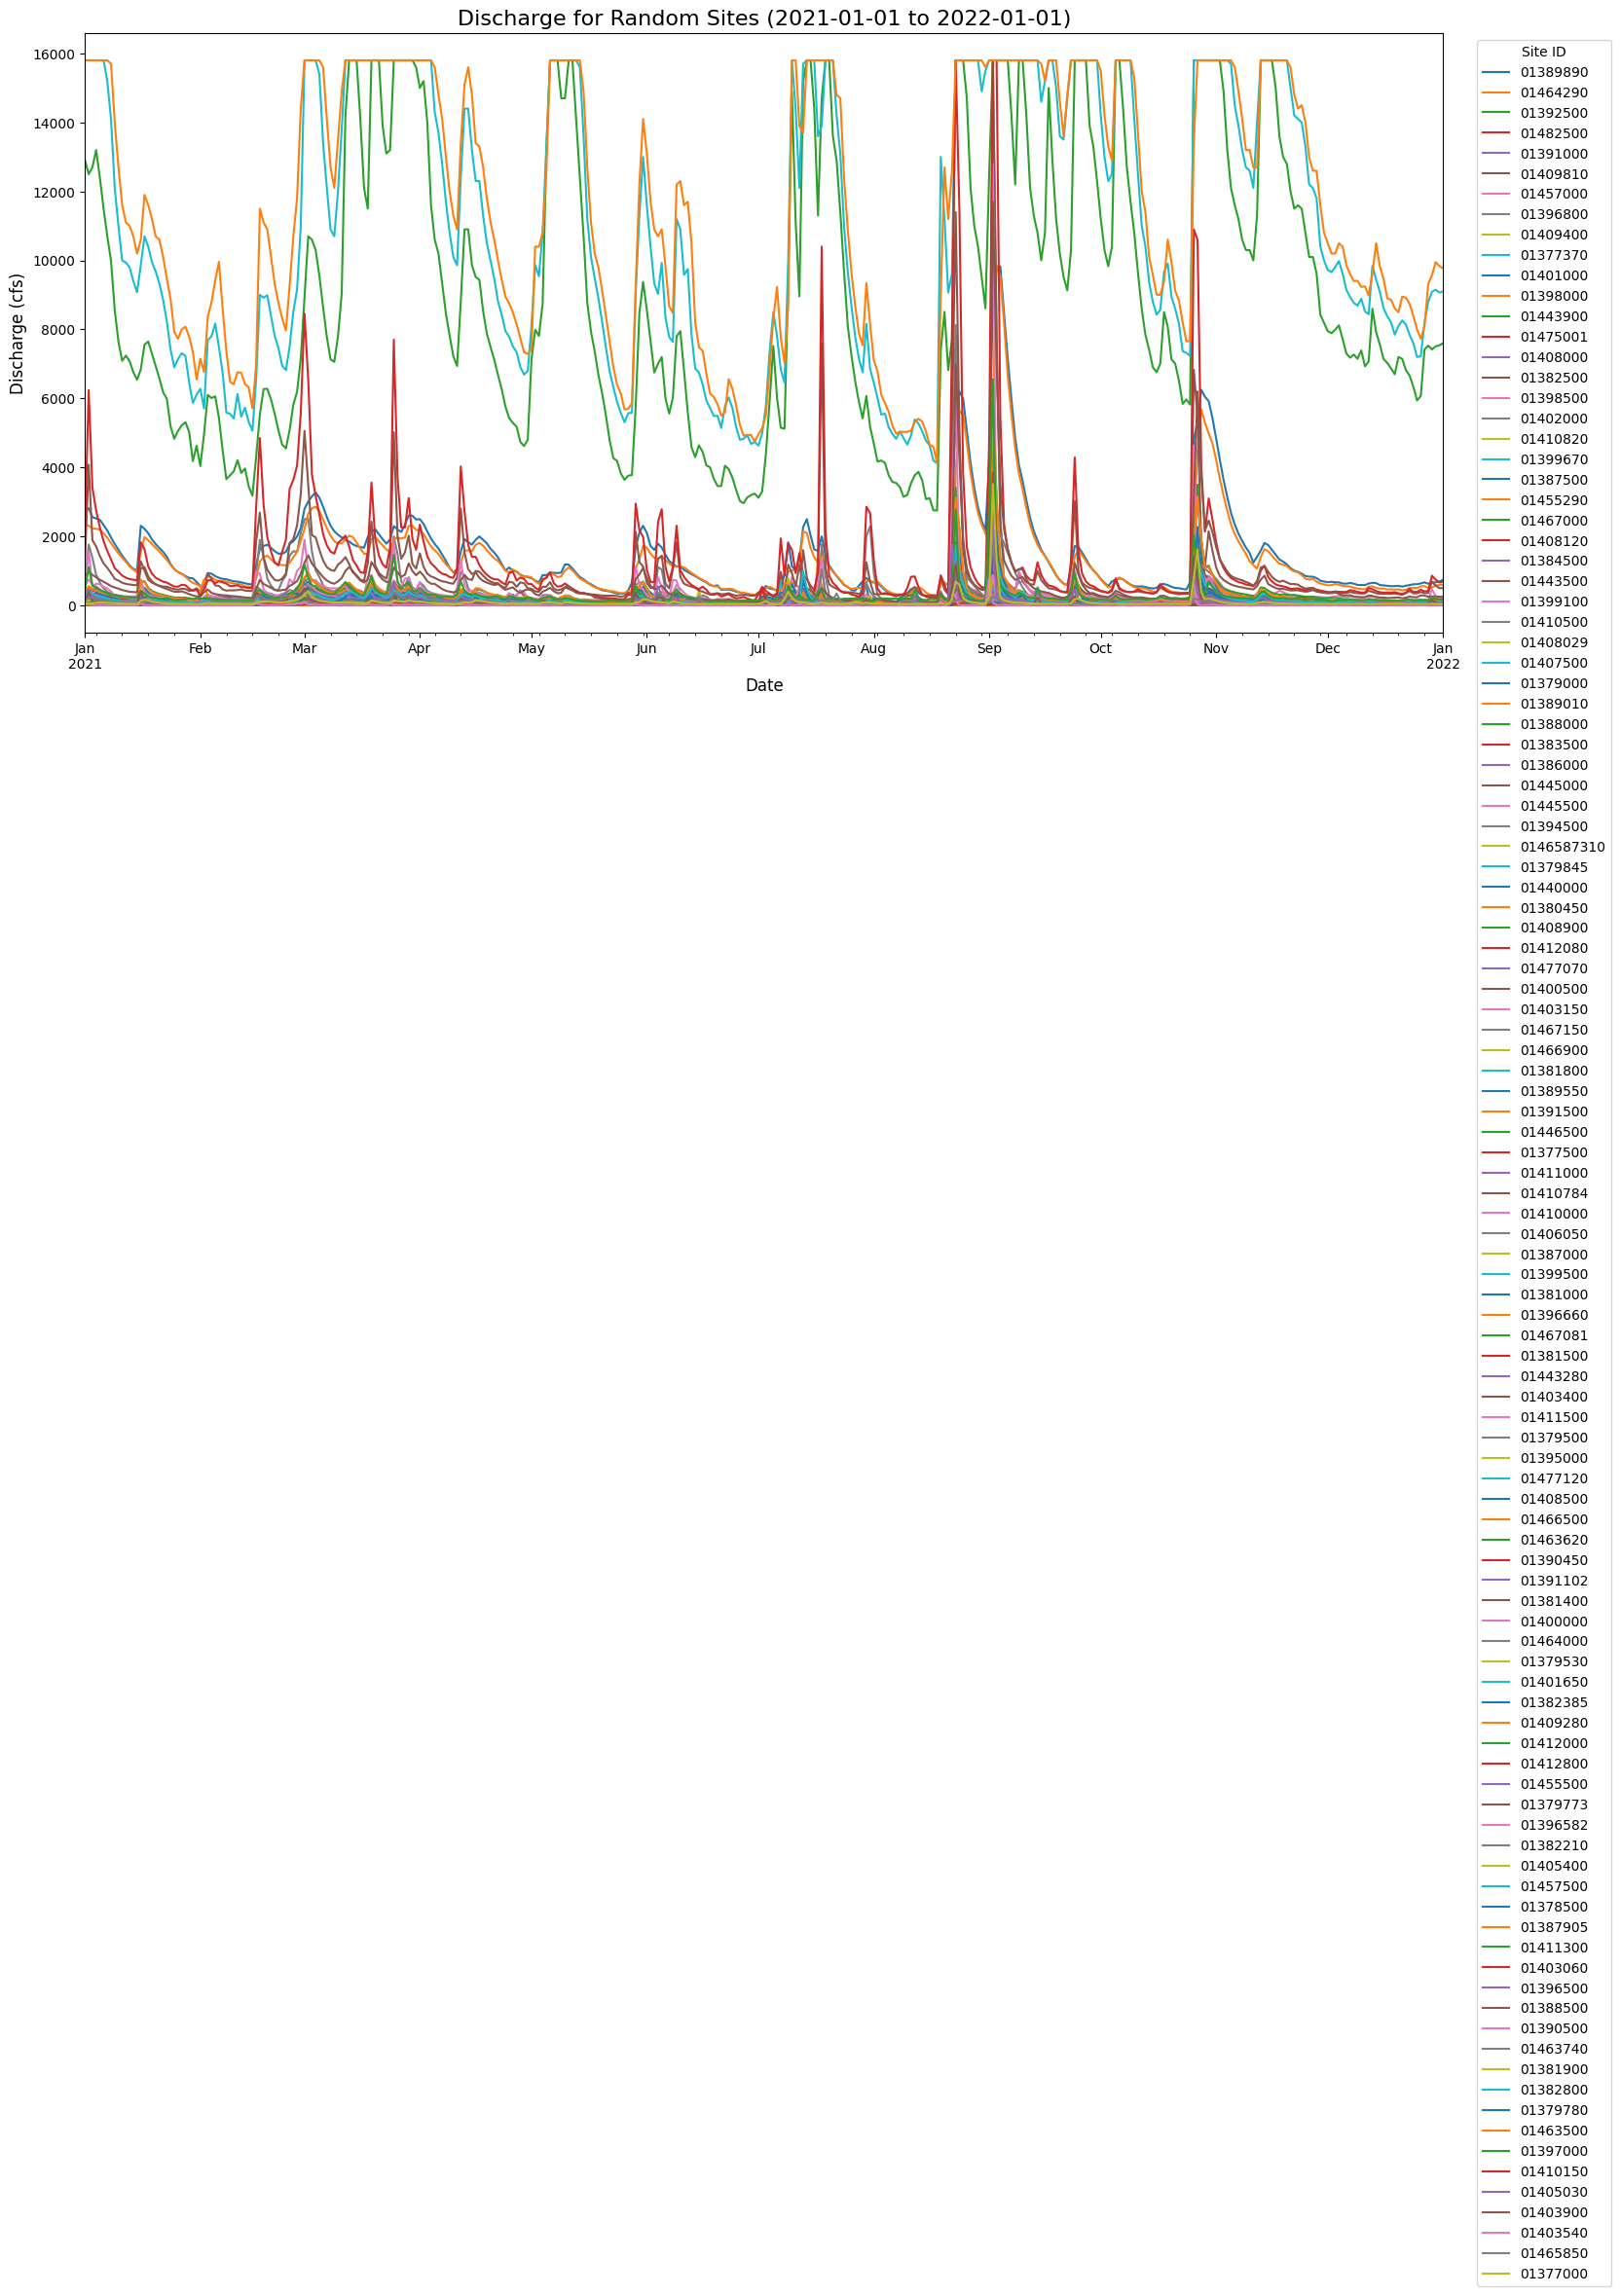

In [11]:
num_sites_to_plot = 109
random_sites = random.sample(list(discharge_pivot.columns), num_sites_to_plot)
start_date = "2021-01-01"
end_date = "2022-01-01" 
print(discharge_pivot.head())
# Filter the data for the selected sites and time range
plot_data = discharge_pivot.loc[start_date:end_date, random_sites]

print(plot_data.head())
# --- Plot the Data ---
fig, ax = plt.subplots(figsize=(18, 8))

plot_data.plot(ax=ax, linestyle='-')

ax.set_title(f'Discharge for Random Sites ({start_date} to {end_date})', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (cfs)', fontsize=12)
ax.legend(title='Site ID', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

siteCode    01377000  01377370  01377500  01378500  01379000  01379500  \
dateTime                                                                 
2020-01-01     217.0      21.5      59.0     238.0     195.0     320.0   
2020-01-02     150.0      16.6      43.0     123.0     172.0     317.0   
2020-01-03     120.0      17.5      42.1      98.3     150.0     289.0   
2020-01-04     119.0      26.5      66.2     127.0     146.0     291.0   
2020-01-05     114.0      16.7      48.5     114.0     154.0     263.0   

siteCode    01379530  01379773  01379780  01379845  ...  0146587310  01466500  \
dateTime                                            ...                         
2020-01-01      18.0      23.8      27.5     162.0  ...        36.3      2.39   
2020-01-02      11.8      22.1      26.3     136.0  ...        31.6      2.28   
2020-01-03      10.9      20.8      24.9     126.0  ...        31.5      2.20   
2020-01-04      36.6      23.1      27.2     159.0  ...        35.3      2.2

/tmp/ipykernel_2761060/3762294869.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


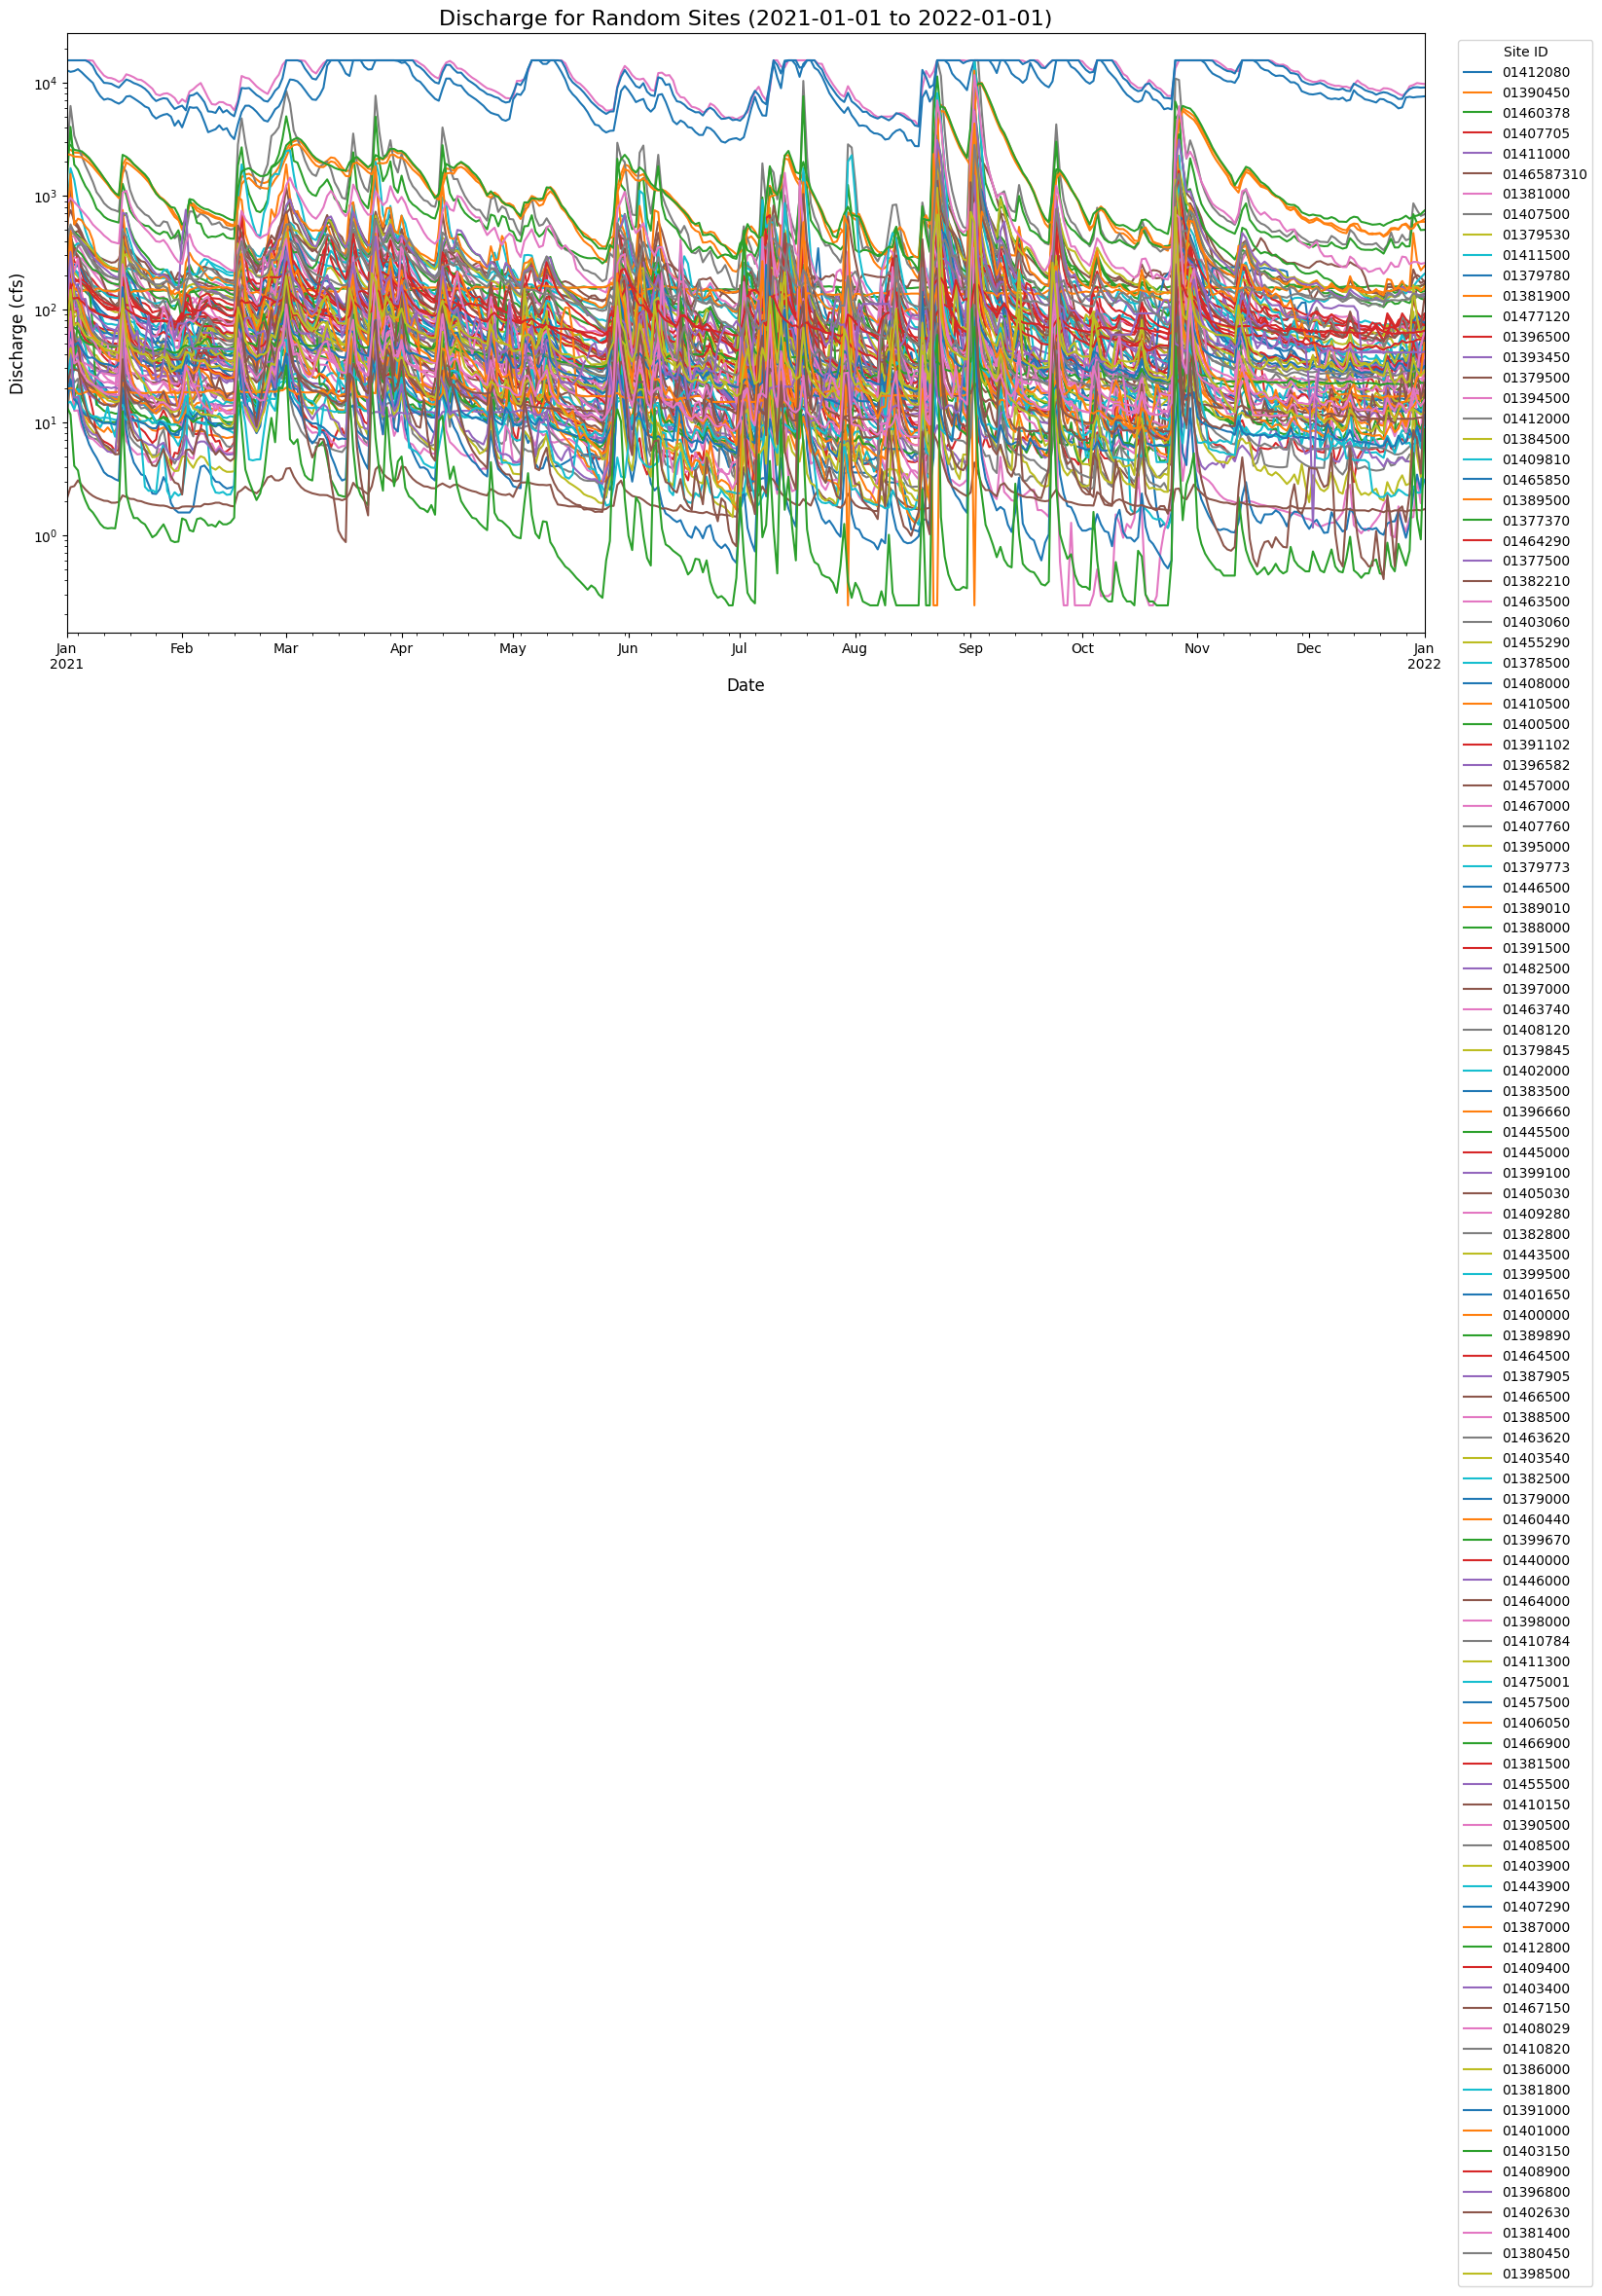

In [12]:
num_sites_to_plot = 109
random_sites = random.sample(list(discharge_pivot.columns), num_sites_to_plot)
start_date = "2021-01-01"
end_date = "2022-01-01" 
print(discharge_pivot.head())
# Filter the data for the selected sites and time range
plot_data = discharge_pivot.loc[start_date:end_date, random_sites]

print(plot_data.head())
# --- Plot the Data ---
fig, ax = plt.subplots(figsize=(18, 8))

plot_data.plot(ax=ax, linestyle='-', logy= True)

ax.set_title(f'Discharge for Random Sites ({start_date} to {end_date})', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (cfs)', fontsize=12)
ax.legend(title='Site ID', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Discretizing data into 100 bins using quantiles...
Discretization complete.

Sample of discretized data:
siteCode    01446500  01445500  01383500  01410150  01412080  01475001  \
dateTime                                                                 
2021-01-01        77        79        84        67        68        86   
2021-01-02        76        89        83        88        85        96   
2021-01-03        76        85        82        88        90        89   
2021-01-04        78        81        79        87        89        90   
2021-01-05        75        78        75        83        87        78   

siteCode    01381000  01381400  01396582  01401650  ...  01446000  01466900  \
dateTime                                            ...                       
2021-01-01        87        78        96        92  ...        81       0.0   
2021-01-02        91        95        97        97  ...        87       0.0   
2021-01-03        90        82        88        88  ...     

  0%|          | 0/1225 [00:00<?, ?it/s]

Mutual information calculation complete.

Mutual Information Matrix (sample):
siteCode  01446500  01445500  01383500  01410150  01412080
siteCode                                                  
01446500  4.180686  2.948769  2.958714  2.753174  2.867388
01445500  2.948769  4.516350  3.231844  3.040024  3.141019
01383500  2.958714  3.231844  4.557525  3.111501  3.212496
01410150  2.753174  3.040024  3.111501  4.366633  3.077491
01412080  2.867388  3.141019  3.212496  3.077491  4.512152

Visualizing the results as a heatmap...


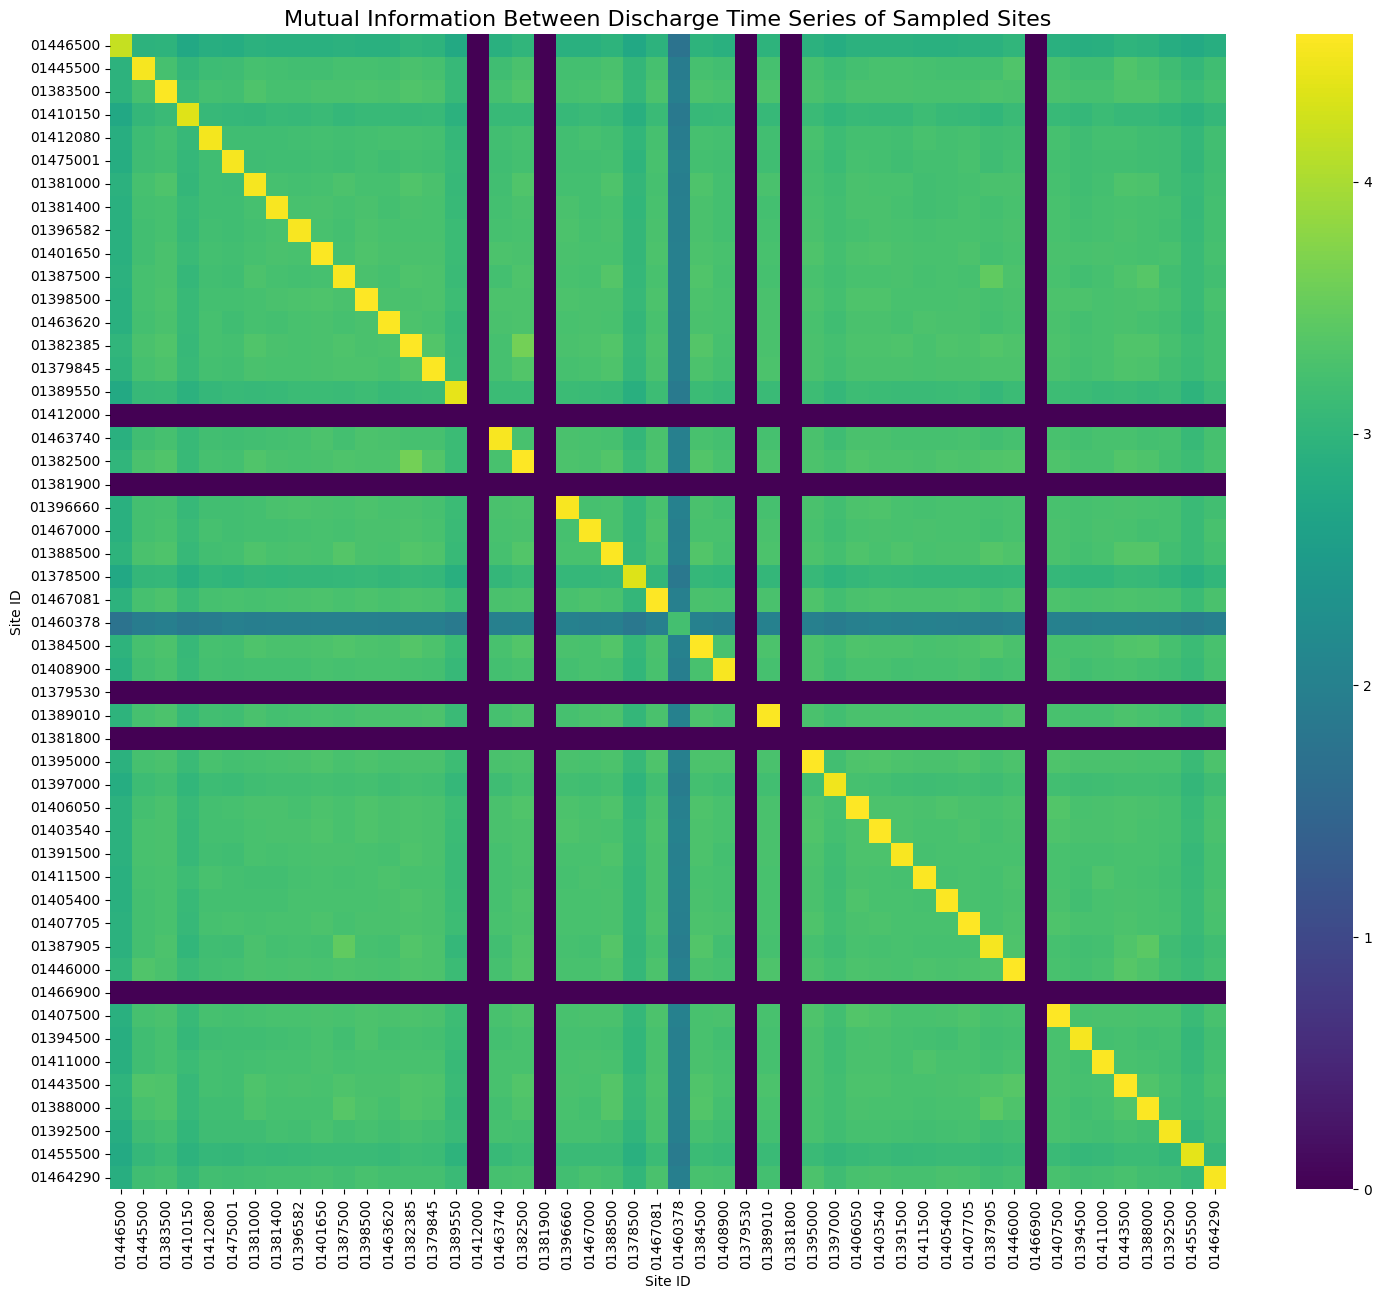

In [13]:

N_BINS = 100 # This is a key parameter. More bins capture more detail but require more data.
start_date = "2021-01-01"
end_date = "2022-01-01" 
random_sites = random.sample(list(discharge_pivot.columns), 50)

print(f"Discretizing data into {N_BINS} bins using quantiles...")
discretized_df = discharge_pivot.loc[start_date:end_date, random_sites].apply(
    lambda x: pd.qcut(x, q=N_BINS, labels=False, duplicates='drop')
).fillna(0)
print("Discretization complete.")
print("\nSample of discretized data:")
print(discretized_df.head())

sites = discretized_df.columns
mi_matrix = pd.DataFrame(np.zeros((len(sites), len(sites))), index=sites, columns=sites)

print("\nCalculating pairwise mutual information matrix...")
# Use itertools.combinations for an efficient way to get all unique pairs
for site1, site2 in tqdm(list(itertools.combinations(sites, 2))):
    # Calculate the MI score
    score = mutual_info_score(discretized_df[site1], discretized_df[site2])
    # The matrix is symmetric, so we fill both entries
    mi_matrix.loc[site1, site2] = score
    mi_matrix.loc[site2, site1] = score

# The MI of a variable with itself is its entropy. We can calculate this for the diagonal.
for site in sites:
    mi_matrix.loc[site, site] = mutual_info_score(discretized_df[site], discretized_df[site])

print("Mutual information calculation complete.")
print("\nMutual Information Matrix (sample):")
print(mi_matrix.iloc[:5, :5])


# In[5]:
# --- Step 4: Visualize the Mutual Information Matrix ---
print("\nVisualizing the results as a heatmap...")

plt.figure(figsize=(18, 15))
sns.heatmap(
    mi_matrix,
    cmap='viridis',
    annot=False # Annotating is not feasible for this many sites
)
plt.title('Mutual Information Between Discharge Time Series of Sampled Sites', fontsize=16)
plt.xlabel('Site ID')
plt.ylabel('Site ID')
plt.show()



Calculating Pearson correlation matrix...
Pearson correlation calculation complete.

Pearson Correlation Matrix (sample):
siteCode  01381800  01382210  01382385  01382500  01382800
siteCode                                                  
01381800  1.000000  0.629116  0.735760  0.707278  0.717651
01382210  0.629116  1.000000  0.945052  0.940701  0.922448
01382385  0.735760  0.945052  1.000000  0.995566  0.987477
01382500  0.707278  0.940701  0.995566  1.000000  0.990925
01382800  0.717651  0.922448  0.987477  0.990925  1.000000


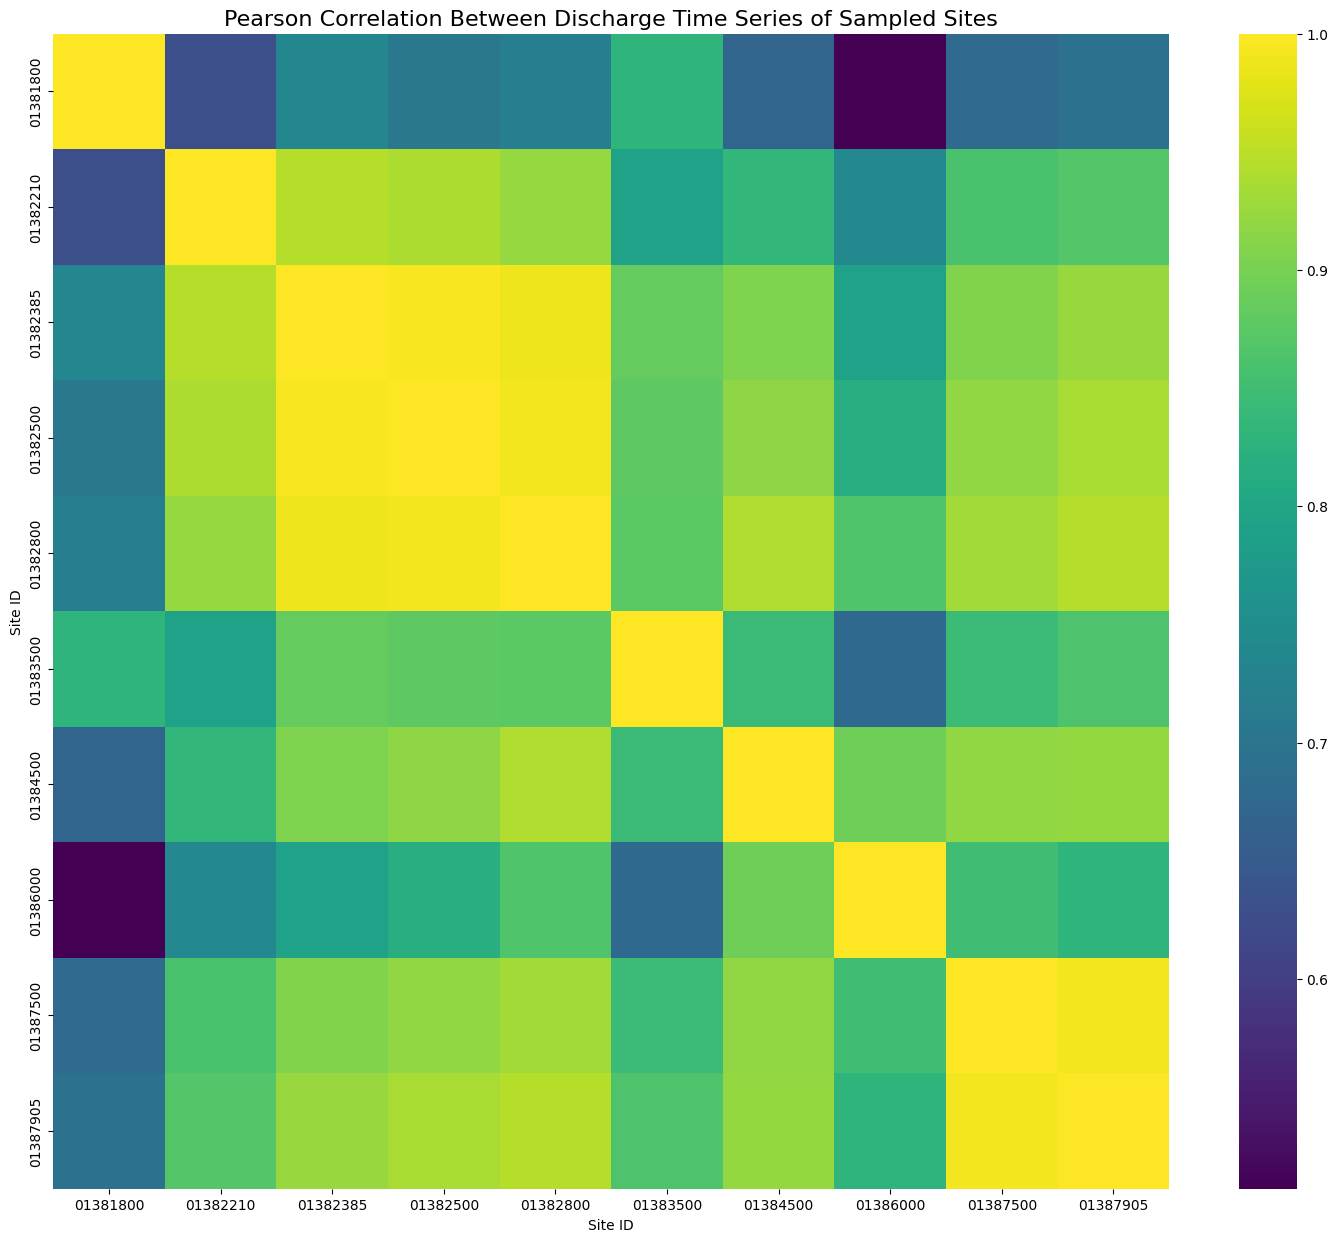

In [54]:
PROCESSED_DATA_DIR = Path("processed_data")
ADJ_MATRIX_PATH = "processed_discharge_only/new_adjacency_matrix.pkl"
BASIN_CHARS_PATH = Path("data/basin_characteristics.csv") # Used for getting site IDs

all_sites = pd.read_csv(BASIN_CHARS_PATH, dtype={'site_no': str})['site_no'].astype(str).tolist()[10:20]

print("\nCalculating Pearson correlation matrix...")
pearson_corr_matrix = discharge_pivot[all_sites].corr(method='pearson')
print("Pearson correlation calculation complete.")
print("\nPearson Correlation Matrix (sample):")
print(pearson_corr_matrix.iloc[:5, :5])

# Visualize the Pearson correlation matrix
plt.figure(figsize=(18, 15))
sns.heatmap(
    pearson_corr_matrix,
    cmap='viridis',
    annot=False
)
plt.title('Pearson Correlation Between Discharge Time Series of Sampled Sites', fontsize=16)
plt.xlabel('Site ID')
plt.ylabel('Site ID')
plt.show()

# plt.savefig(EDA_OUTPUT_DIR / "pearson_correlation_matrix.png", bbox_inches='tight')


Calculating Spearman correlation matrix...
Spearman correlation calculation complete.

Spearman Correlation Matrix (sample):
siteCode  01381800  01382210  01382385  01382500  01382800
siteCode                                                  
01381800  1.000000  0.337738  0.722395  0.794468  0.837472
01382210  0.337738  1.000000  0.736899  0.702502  0.652605
01382385  0.722395  0.736899  1.000000  0.986993  0.962194
01382500  0.794468  0.702502  0.986993  1.000000  0.980575
01382800  0.837472  0.652605  0.962194  0.980575  1.000000


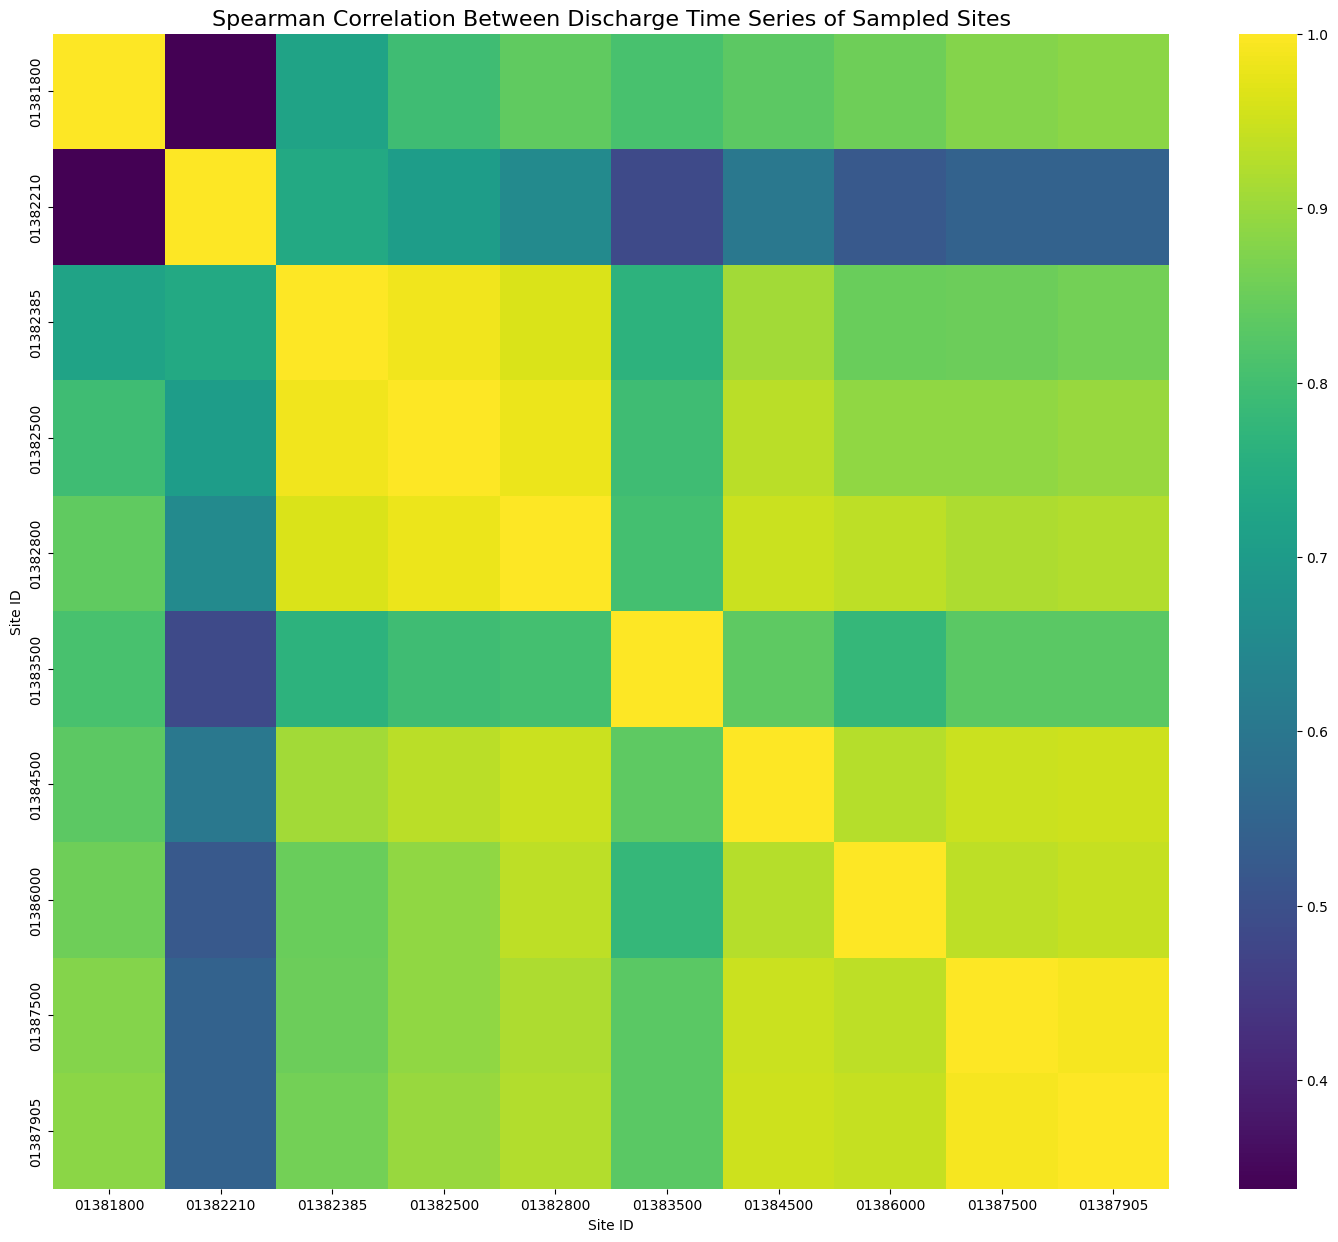

In [55]:

# In[4]:
# --- Step 3: Calculate Spearman Correlation Matrix ---
# Spearman correlation measures the monotonic relationship (rank-based).
# It's often more robust for non-linear relationships, which are common in hydrology.
print("\nCalculating Spearman correlation matrix...")
spearman_corr_matrix = discharge_pivot[all_sites].corr(method='spearman')

print("Spearman correlation calculation complete.")
print("\nSpearman Correlation Matrix (sample):")
print(spearman_corr_matrix.iloc[:5, :5])

# Visualize the Spearman correlation matrix
plt.figure(figsize=(18, 15))
sns.heatmap(
    spearman_corr_matrix,
    cmap='viridis',
    annot=False
)
plt.title('Spearman Correlation Between Discharge Time Series of Sampled Sites', fontsize=16)
plt.xlabel('Site ID')
plt.ylabel('Site ID')
plt.show()
# plt.savefig(EDA_OUTPUT_DIR / "spearman_correlation_matrix.png", bbox_inches='tight')


Adjacency matrix loaded successfully with shape: (109, 109)

Plotting the full adjacency matrix to show overall graph structure...
[[0.00908961 0.00908961 0.00908961 0.00908961 0.00908961 0.00922843
  0.00930388 0.00908961 0.0091422  0.00908961]
 [0.00904852 0.00904852 0.00904852 0.0092025  0.00904852 0.00932089
  0.00930199 0.00921237 0.00906936 0.00904852]
 [0.00914847 0.00914847 0.00914847 0.00914847 0.00914847 0.00919501
  0.00919391 0.00926751 0.0091756  0.00914847]
 [0.00812324 0.00690843 0.00690843 0.00710836 0.00704117 0.00690843
  0.00718479 0.00690843 0.00690843 0.00690843]
 [0.00884254 0.0089356  0.00884254 0.00884254 0.00904778 0.00884254
  0.00911367 0.0116014  0.00998001 0.00884254]
 [0.00873887 0.00873887 0.00873887 0.00952697 0.00873997 0.00957947
  0.0088717  0.00898532 0.00956048 0.00873887]
 [0.00974619 0.00915221 0.00862473 0.00853441 0.0102146  0.00853441
  0.00864752 0.00853441 0.00878863 0.00853441]
 [0.00909182 0.00909182 0.00909182 0.00909182 0.00909182 0.00915

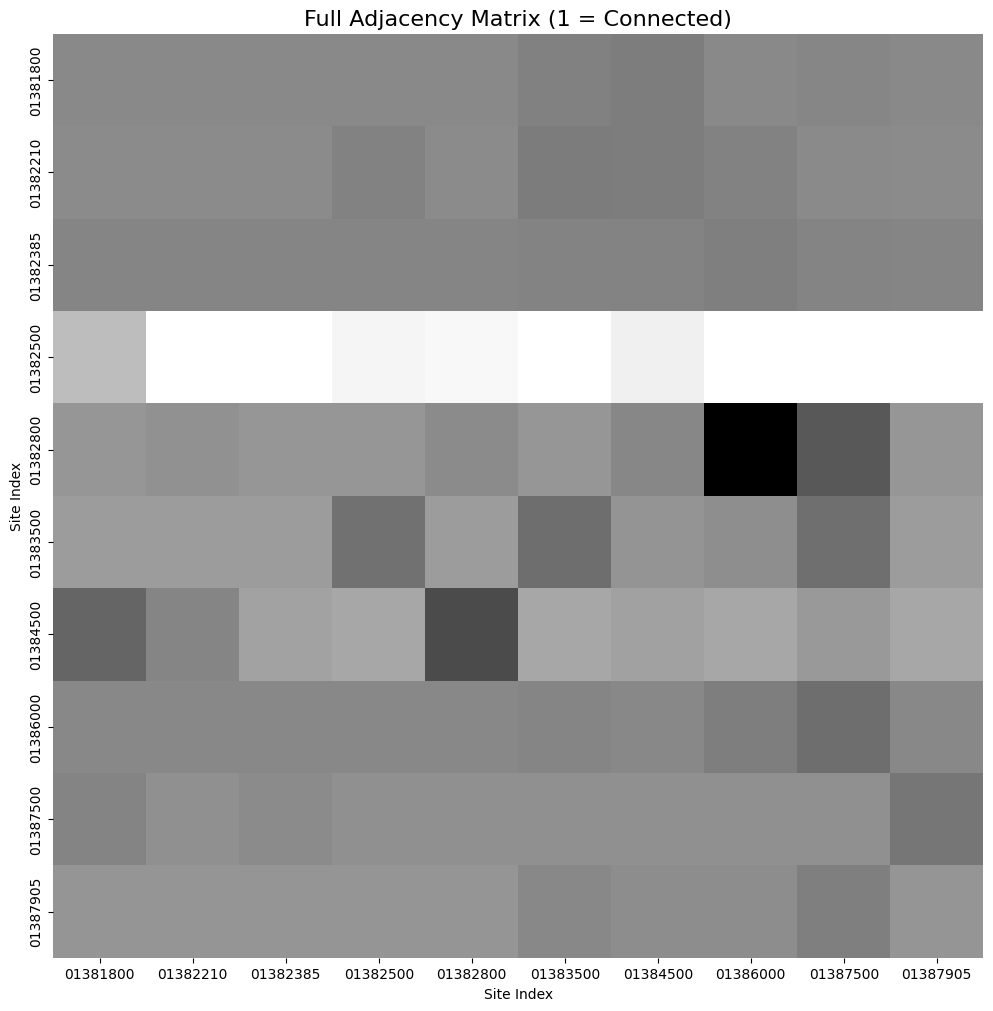

In [57]:
import pickle

PROCESSED_DATA_DIR = Path("processed_data")
ADJ_MATRIX_PATH = "processed_discharge_only/new_adjacency_matrix.pkl"
BASIN_CHARS_PATH = Path("data/basin_characteristics.csv") # Used for getting site IDs

with open(ADJ_MATRIX_PATH, 'rb') as f:
        adj_matrix = pickle.load(f)
    
all_sites = pd.read_csv(BASIN_CHARS_PATH, dtype = {'site_no': str})['site_no'].astype(str).tolist()
site_labels = all_sites[10:20]

print(f"Adjacency matrix loaded successfully with shape: {adj_matrix.shape}")
print("\nPlotting the full adjacency matrix to show overall graph structure...")

print(adj_matrix[10:20,10:20])
plt.figure(figsize=(12, 12))
sns.heatmap(
    adj_matrix[10:20,10:20], # Display only the first 10 rows and columns for clarity
    cmap='gray_r', # Use a reverse grayscale map (1=black, 0=white)
    cbar=False,    # No color bar needed for a binary matrix
    xticklabels=site_labels,
    yticklabels=site_labels,
)
plt.title('Full Adjacency Matrix (1 = Connected)', fontsize=16)
plt.xlabel('Site Index')
plt.ylabel('Site Index')
plt.show()
# plt.savefig(EDA_OUTPUT_DIR / "adj_matrix.png", bbox_inches='tight')


In [4]:
# Plot discharge sites with only 0 values from discharge_pivot
print("\nPlotting discharge sites with only 0 values...")
zero_sites = discharge_pivot.columns[(discharge_pivot == 0).all()]
if zero_sites.empty:
    print("No sites with only 0 values found.") 
else:
    print(f"Found {len(zero_sites)} sites with only 0 values: {zero_sites.tolist()}")
    plt.figure(figsize=(10, 6))
    sns.barplot(x=zero_sites, y=[0]*len(zero_sites), color='red')
    plt.title('Discharge Sites with Only 0 Values')
    plt.xlabel('Site ID')
    plt.ylabel('Discharge (cfs)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    output_path = EDA_OUTPUT_DIR / "discharge_zero_sites.png"
    plt.savefig(output_path, bbox_inches='tight')
    print(f"Saved zero sites plot to {output_path}")
    plt.show()


Plotting discharge sites with only 0 values...
No sites with only 0 values found.


In [6]:
# Plot discharge sites with only NaNs values from discharge_pivot
print("\nPlotting discharge sites with only NaNs values...")
zero_sites = discharge_pivot.columns[(discharge_pivot.isna()).all()]
if zero_sites.empty:
    print("No sites with only NaNs values found.") 
else:
    print(f"Found {len(zero_sites)} sites with only NaNs values: {zero_sites.tolist()}")
    plt.figure(figsize=(10, 6))
    sns.barplot(x=zero_sites, y=[0]*len(zero_sites), color='red')
    plt.title('Discharge Sites with Only NaNs Values')
    plt.xlabel('Site ID')
    plt.ylabel('Discharge (cfs)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    output_path = EDA_OUTPUT_DIR / "discharge_nan_sites.png"
    plt.savefig(output_path, bbox_inches='tight')
    print(f"Saved zero sites plot to {output_path}")
    plt.show()


Plotting discharge sites with only NaNs values...
No sites with only NaNs values found.


In [5]:
discharge_pivot

siteCode,01367690,01367800,01367805,01377000,01377370,01377500,01378500,01379000,01379500,01379530,...,0146587310,01466500,01466900,01467000,01467081,01467150,01475001,01477070,01477120,01482500
dateTime,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,NaN,NaN,120.0,NaN,42.0,0.71,41.0,168.0,NaN,...,NaN,2.40,NaN,193.0,103.00,134.0,NaN,NaN,202.0,130.00
1990-01-02,NaN,NaN,NaN,111.0,NaN,30.0,0.63,46.0,160.0,NaN,...,NaN,2.30,NaN,216.0,14.00,36.0,NaN,NaN,61.0,30.00
1990-01-03,NaN,NaN,NaN,108.0,NaN,27.0,0.44,36.0,106.0,NaN,...,NaN,2.10,NaN,205.0,10.00,23.0,NaN,NaN,38.0,NaN
1990-01-04,NaN,NaN,NaN,109.0,NaN,27.0,0.37,32.0,76.0,NaN,...,NaN,2.00,NaN,188.0,9.50,21.0,NaN,NaN,35.0,NaN
1990-01-05,NaN,NaN,NaN,109.0,NaN,27.0,0.89,45.0,68.0,NaN,...,NaN,2.00,NaN,183.0,10.00,22.0,NaN,NaN,36.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,NaN,NaN,NaN,33.3,6.09,23.9,4.59,22.2,54.9,2.07,...,NaN,0.86,26.5,45.0,4.87,9.4,6.35,2.81,18.8,5.68
2024-12-28,NaN,NaN,NaN,38.3,14.50,33.0,4.54,36.6,85.6,13.90,...,NaN,0.89,29.0,54.4,20.60,29.0,8.05,3.74,25.8,7.91
2024-12-29,NaN,NaN,NaN,43.5,25.30,57.7,7.07,98.9,171.0,26.00,...,NaN,0.92,38.3,75.3,22.50,36.5,8.81,4.53,30.4,12.60
